In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/drive/MyDrive/Infosys_ImpactSense/earthquake_alert_balanced_dataset.csv")
df = df.drop_duplicates()
label_encoder = LabelEncoder()

df['alert_encoded'] = label_encoder.fit_transform(df['alert'])
X = df[['magnitude','depth','cdi','mmi','sig']]
y = df['alert_encoded']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(X_scaled[:5])

[[-0.14368925 -0.35251926  0.46332255  0.06015067  0.16688225]
 [-0.3800351  -0.24860618 -1.31901473 -2.14031285 -0.36242105]
 [-0.14368925  4.98483439 -1.76459904 -2.87380069 -0.04163117]
 [ 0.56534831 -0.13524645 -0.87343041 -1.40682501  1.20944935]
 [-1.08907265  5.40993335 -3.101352   -3.60728853 -1.40498815]]


In [ ]:
print(y.head(20))

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     3
9     3
10    3
11    0
12    0
13    3
14    1
15    0
16    3
17    0
18    0
19    0
Name: alert_encoded, dtype: int64


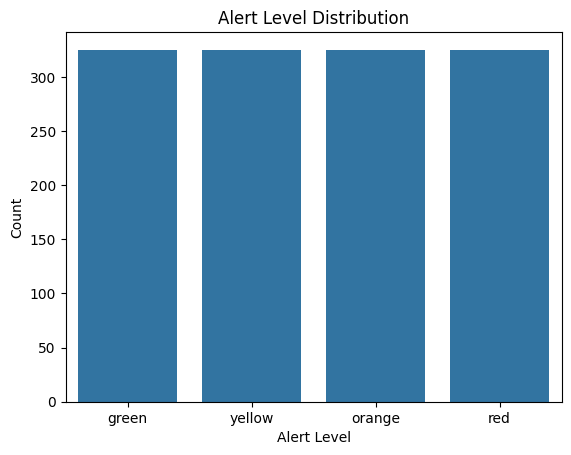

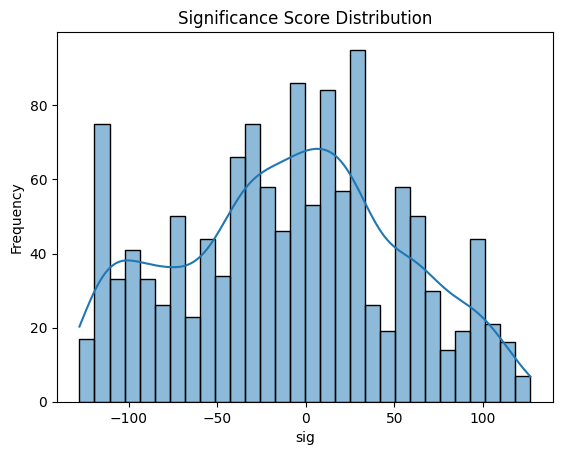

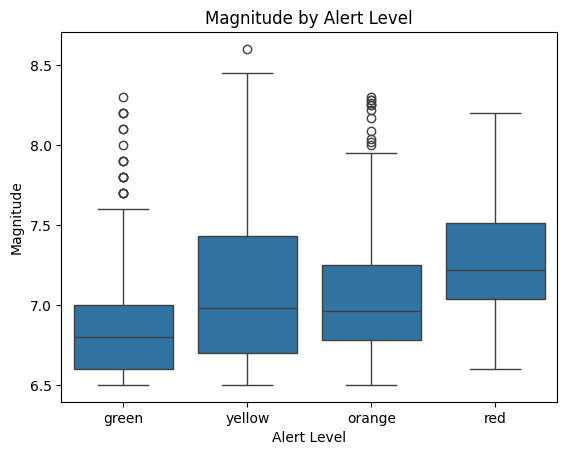

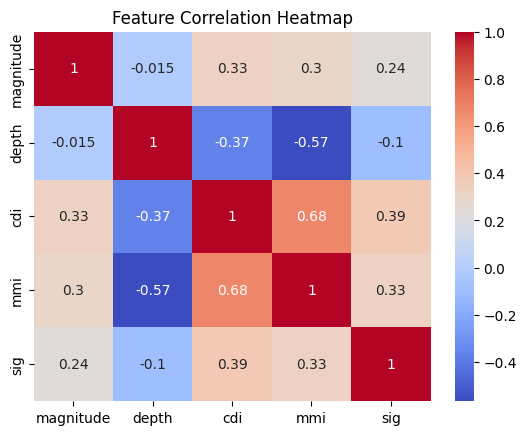

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Infosys_ImpactSense/earthquake_alert_balanced_dataset.csv")

df['alert_encoded'] = pd.Categorical(df['alert']).codes

sns.countplot(x='alert', data=df)
plt.title("Alert Level Distribution")
plt.xlabel("Alert Level")
plt.ylabel("Count")

plt.show()

sns.histplot(df['sig'], bins=30, kde=True)
plt.title("Significance Score Distribution")
plt.xlabel("sig")
plt.ylabel("Frequency")
plt.show()

sns.boxplot(x='alert', y='magnitude', data=df)
plt.title("Magnitude by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Magnitude")
plt.show()

corr = df[['magnitude', 'depth', 'cdi', 'mmi', 'sig']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression MAE:", mean_absolute_error(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6547619047619048
Logistic Regression MAE: 0.6468253968253969


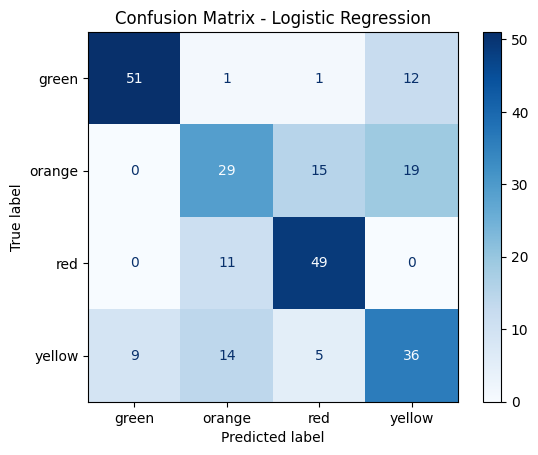

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree MAE:", mean_absolute_error(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8650793650793651
Decision Tree MAE: 0.29365079365079366


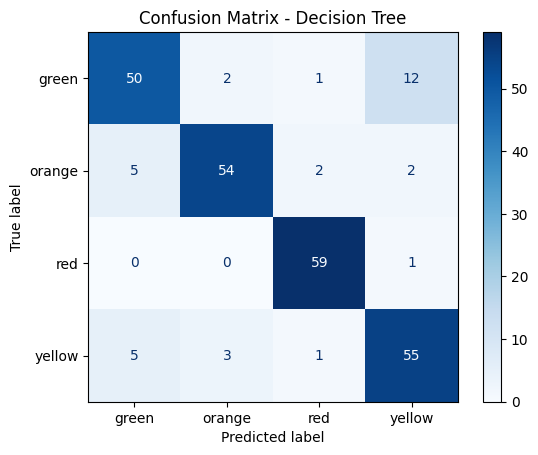

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Random Forest Accuracy: 0.9325396825396826

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.86      0.91        65
           1       0.97      0.97      0.97        63
           2       0.94      0.98      0.96        60
           3       0.87      0.92      0.89        64

    accuracy                           0.93       252
   macro avg       0.93      0.93      0.93       252
weighted avg       0.93      0.93      0.93       252

Confusion Matrix:
 [[56  0  1  8]
 [ 0 61  1  1]
 [ 0  1 59  0]
 [ 2  1  2 59]]


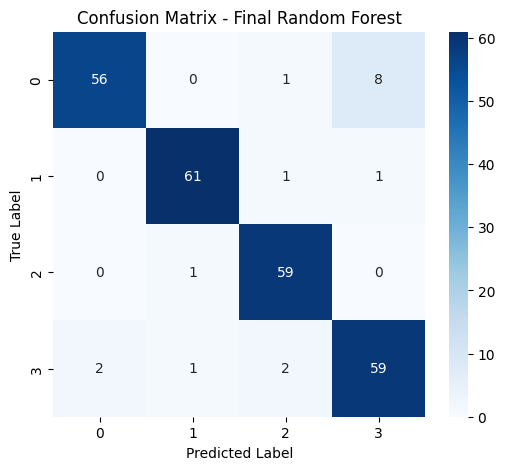


Top 10 Important Features:
     Feature  Importance
4        sig    0.243576
3        mmi    0.242487
1      depth    0.191288
0  magnitude    0.167829
2        cdi    0.154821

Number of misclassified samples: 17
True Label: 0 | Predicted Label: 3
True Label: 0 | Predicted Label: 3
True Label: 2 | Predicted Label: 1
True Label: 0 | Predicted Label: 3
True Label: 3 | Predicted Label: 2

Model and scaler saved successfully.

Inference Prediction for one sample: 1


In [ ]:
# ==================================================
# FINAL RANDOM FOREST (NO WARNINGS, DEPLOYMENT SAFE)
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --------------------------------------------------
# 1. TRAIN–TEST SPLIT
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 2. FEATURE SCALING (KEEP FEATURE NAMES)
# --------------------------------------------------
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# --------------------------------------------------
# 3. RANDOM FOREST MODEL (FINAL VERSION)
# --------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 4. PREDICTION
# --------------------------------------------------
y_pred = rf_model.predict(X_test_scaled)

# --------------------------------------------------
# 5. EVALUATION
# --------------------------------------------------
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# --------------------------------------------------
# 6. CONFUSION MATRIX PLOT
# --------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Random Forest")
plt.show()

# --------------------------------------------------
# 7. FEATURE IMPORTANCE
# --------------------------------------------------
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# --------------------------------------------------
# 8. MISCLASSIFIED SAMPLES
# --------------------------------------------------
mis_idx = np.where(y_test != y_pred)[0]
print("\nNumber of misclassified samples:", len(mis_idx))

for i in mis_idx[:5]:
    print(f"True Label: {y_test.iloc[i]} | Predicted Label: {y_pred[i]}")

# --------------------------------------------------
# 9. SAVE MODEL & SCALER
# --------------------------------------------------
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully.")

# --------------------------------------------------
# 10. LOAD MODEL & INFERENCE (NO WARNING)
# --------------------------------------------------
loaded_model = joblib.load("random_forest_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample_df = X.iloc[[0]]  # KEEP AS DATAFRAME
sample_scaled = pd.DataFrame(
    loaded_scaler.transform(sample_df),
    columns=sample_df.columns
)

prediction = loaded_model.predict(sample_scaled)

print("\nInference Prediction for one sample:", prediction[0])


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# Load the initial Random Forest model and scaler
# Ensure these files are created by the initial RF training cell (e.g., 'rf_model_training').
try:
    initial_rf_model = joblib.load('random_forest_model.pkl')
    initial_scaler = joblib.load('scaler.pkl') # Assuming the scaler was saved with the same name
except FileNotFoundError:
    print("Error: Initial Random Forest model or scaler file not found. Please ensure the initial RF training step was completed and saved the model/scaler correctly.")
    raise

# Re-initialize label_encoder (as it was not saved implicitly)
df_original = pd.read_csv("/content/drive/MyDrive/Infosys_ImpactSense/earthquake_alert_balanced_dataset.csv")
label_encoder = LabelEncoder()
label_encoder.fit(df_original['alert'])

# Create input widgets
magnitude_input_initial = widgets.FloatText(description='Magnitude:', value=7.0)
depth_input_initial = widgets.FloatText(description='Depth:', value=10.0)
cdi_input_initial = widgets.FloatText(description='CDI:', value=5.0)
mmi_input_initial = widgets.FloatText(description='MMI:', value=4.0)
sig_input_initial = widgets.FloatText(description='Sig:', value=20.0)

predict_button_initial = widgets.Button(description='Predict Alert (Initial RF Model)')
output_widget_initial = widgets.Output()

def predict_alert_initial(b):
    with output_widget_initial:
        output_widget_initial.clear_output()

        # Get input values
        input_data = {
            'magnitude': [magnitude_input_initial.value],
            'depth': [depth_input_initial.value],
            'cdi': [cdi_input_initial.value],
            'mmi': [mmi_input_initial.value],
            'sig': [sig_input_initial.value]
        }

        # Create DataFrame from input
        input_df = pd.DataFrame(input_data)

        # Scale the input data using the loaded scaler
        input_scaled = initial_scaler.transform(input_df)

        # Make prediction using the loaded initial Random Forest model
        prediction_encoded = initial_rf_model.predict(input_scaled)

        # Inverse transform to get original alert level
        predicted_alert = label_encoder.inverse_transform(prediction_encoded)

        print(f"Predicted Alert Level (Initial RF Model): {predicted_alert[0]}")

# Link button to prediction function
predict_button_initial.on_click(predict_alert_initial)

# Display widgets
display(magnitude_input_initial, depth_input_initial, cdi_input_initial, mmi_input_initial, sig_input_initial, predict_button_initial, output_widget_initial)


FloatText(value=7.0, description='Magnitude:')

FloatText(value=10.0, description='Depth:')

FloatText(value=5.0, description='CDI:')

FloatText(value=4.0, description='MMI:')

FloatText(value=20.0, description='Sig:')

Button(description='Predict Alert (Initial RF Model)', style=ButtonStyle())

Output()

In [ ]:
app_py_content_updated = """
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import base64

from flask import Flask, request, render_template, redirect, url_for, flash, session

app = Flask(__name__)
app.secret_key = 'super_secret_key_for_session'

# Load the pre-trained model, scaler, and feature names
MODEL_PATH = 'earthquake_rf_model.pkl'
SCALER_PATH = 'earthquake_scaler.pkl'
FEATURE_NAMES_PATH = 'feature_names.pkl'

try:
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    feature_names = joblib.load(FEATURE_NAMES_PATH)
    print(f"Successfully loaded model from {MODEL_PATH}")
    print(f"Successfully loaded scaler from {SCALER_PATH}")
    print(f"Successfully loaded feature names from {FEATURE_NAMES_PATH}")
except FileNotFoundError:
    print(f"Error: One or more necessary files ({MODEL_PATH}, {SCALER_PATH}, {FEATURE_NAMES_PATH}) not found.")
    print("Please ensure the model training script was run successfully and these files exist in the same directory as app.py.")
    exit()

# Define alert level mappings and colors
alert_to_class = {
    "green": 0,
    "yellow": 1,
    "orange": 2,
    "red": 3
}

class_to_alert = {v: k for k, v in alert_to_class.items()}

ALERT_COLORS = {
    "green": "#28a745",  # Bootstrap success green
    "yellow": "#ffc107", # Bootstrap warning yellow
    "orange": "#fd7e14", # Bootstrap orange
    "red": "#dc3545"     # Bootstrap danger red
}

@app.route('/', methods=['GET', 'POST'])
def index():
    prediction_result = None
    if request.method == 'POST':
        try:
            # Get input values from the form
            magnitude = float(request.form['magnitude'])
            depth = float(request.form['depth'])
            cdi = float(request.form['cdi'])
            mmi = float(request.form['mmi'])
            sig = float(request.form['sig'])

            # Create a DataFrame from the input
            input_data = pd.DataFrame([{
                'magnitude': magnitude,
                'depth': depth,
                'cdi': cdi,
                'mmi': mmi,
                'sig': sig
            }])

            # Ensure the input features are in the correct order
            input_data = input_data[feature_names]

            # Scale the input data
            scaled_input = scaler.transform(input_data)

            # Make prediction
            predicted_class = model.predict(scaled_input)[0]
            probabilities = model.predict_proba(scaled_input)[0]

            predicted_alert = class_to_alert[predicted_class]
            predicted_color = ALERT_COLORS[predicted_alert]

            # Prepare probabilities for display
            prob_display = {class_to_alert[i].capitalize(): f"{p*100:.2f}%" for i, p in enumerate(probabilities)}

            prediction_result = {
                'alert': predicted_alert.upper(),
                'color': predicted_color,
                'probabilities': prob_display
            }

        except ValueError:
            prediction_result = {'error': 'Invalid input. Please enter numeric values for all fields.'}
        except Exception as e:
            prediction_result = {'error': f'An error occurred during prediction: {e}'}

    return render_template('index.html', prediction_result=prediction_result)

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        username = request.form['username']
        password = request.form['password']

        # Simple mock user check
        if username == 'testuser' and password == 'password':
            session['logged_in'] = True
            flash('Logged in successfully!', 'success')
            return redirect(url_for('index'))
        else:
            error = 'Invalid credentials. Please try again.'
            return render_template('login.html', error=error)
    return render_template('login.html')

@app.route('/signup', methods=['GET', 'POST'])
def signup():
    if request.method == 'POST':
        username = request.form['username']
        password = request.form['password']
        # For demonstration, we'll just acknowledge registration
        # In a real app, you'd save this to a database
        flash(f'User {username} registered successfully! Please login.', 'success')
        return redirect(url_for('login'))
    return render_template('signup.html')

@app.route('/dashboard')
def dashboard():
    return render_template('dashboard.html')

if __name__ == '__main__':
    app.run(debug=True, port=5000, host='0.0.0.0')
"""

with open('app.py', 'w') as f:
    f.write(app_py_content_updated)

print("'app.py' updated with the /dashboard route.")

'app.py' updated with the /dashboard route.


In [ ]:
!pip install flask pandas numpy scikit-learn joblib matplotlib seaborn

In [ ]:
import os

# Create directories
os.makedirs('templates', exist_ok=True)
os.makedirs('static', exist_ok=True)

# Create app.py content
app_py_content = """
from flask import Flask, render_template, request, jsonify
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import base64

app = Flask(__name__)

# Load the pre-trained model, scaler, and feature names
try:
    model = joblib.load('earthquake_rf_model.pkl')
    scaler = joblib.load('earthquake_scaler.pkl')
    feature_names = joblib.load('feature_names.pkl')
    print("Model, scaler, and feature names loaded successfully.")
except FileNotFoundError:
    print("Error: Model or scaler files not found. Please ensure 'earthquake_rf_model.pkl', 'earthquake_scaler.pkl', and 'feature_names.pkl' are in the same directory.")
    # Exit or handle error appropriately
    exit()

# Define alert level mappings
alert_to_class = {
    "green": 0,
    "yellow": 1,
    "orange": 2,
    "red": 3
}
class_to_alert = {v: k for k, v in alert_to_class.items()}

# Define alert colors for UI
ALERT_COLORS = {
    "green": "#28a745",  # Bootstrap green
    "yellow": "#ffc107", # Bootstrap yellow
    "orange": "#fd7e14", # Custom orange for consistency
    "red": "#dc3545"     # Bootstrap red
}

@app.route('/')
def index():
    return render_template('index.html')

if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)
"""

# Write content to app.py
with open('app.py', 'w') as f:
    f.write(app_py_content)

print("Flask project structure initialized:")
print("- 'templates/' directory created.")
print("- 'static/' directory created.")
print("- 'app.py' created with initial Flask setup and model loading code.")


Flask project structure initialized:
- 'templates/' directory created.
- 'static/' directory created.
- 'app.py' created with initial Flask setup and model loading code.


In [ ]:
free_prediction_html = """{% extends \"base.html\" %}

{% block title %}Free Prediction - Quake Pred{% endblock %}

{% block content %}
<section class=\"prediction-section\">
    <div class=\"section-header\">
        <h2>Free Earthquake Prediction</h2>
        <p>Enter seismic parameters below to get instant alert level prediction</p>
    </div>

    <div class=\"alert alert-info\">
        <i class=\"fas fa-info-circle me-2\"></i>
        <strong>Note:</strong> Free predictions are limited. <a href=\"{{ url_for('signup') }}\" class=\"alert-link\">Sign up</a>
        for unlimited predictions, prediction history, and advanced features.
    </div>

    <form method=\"POST\" action=\"{{ url_for('make_prediction') }}\" class=\"needs-validation\" novalidate>
        <div class=\"row\">
            <div class=\"col-md-6\">
                <div class=\"form-group\">
                    <label for=\"magnitude\" class=\"form-label\">
                        <i class=\"fas fa-wave-square me-1\"></i>Magnitude (Richter Scale)
                    </label>
                    <input type=\"number\" step=\"0.01\" class=\"form-control\" id=\"magnitude\" name=\"magnitude\"
                           placeholder=\"e.g., 7.2\" required min=\"1\" max=\"10\">
                    <div class=\"invalid-feedback\">
                        Please enter a valid magnitude between 1.0 and 10.0
                    </div>
                    <small class=\"form-text text-muted\">
                        Earthquake magnitude on Richter scale (1.0 - 10.0)
                    </small>
                </div>
            </div>

            <div class=\"col-md-6\">
                <div class=\"form-group\">
                    <label for=\"depth\" class=\"form-label\">
                        <i class=\"fas fa-mountain me-1\"></i>Depth (km)
                    </label>
                    <input type=\"number\" step=\"0.1\" class=\"form-control\" id=\"depth\" name=\"depth\"
                           placeholder=\"e.g., 10.5\" required min=\"0\" max=\"700\">
                    <div class=\"invalid-feedback\">
                        Please enter a valid depth between 0 and 700 km
                    </div>
                    <small class=\"form-text text-muted\">
                        Depth of earthquake epicenter in kilometers
                    </small>
                </div>
            </div>
        </div>

        <div class=\"row mt-3\">
            <div class=\"col-md-6\">
                <div class=\"form-group\">
                    <label for=\"cdi\" class=\"form-label\">
                        <i class=\"fas fa-users me-1\"></i>CDI (Community Decimal Intensity)
                    </label>
                    <input type=\"number\" step=\"0.1\" class=\"form-control\" id=\"cdi\" name=\"cdi\"
                           placeholder=\"e.g., 8.0\" required min=\"0\" max=\"12\">
                    <div class=\"invalid-feedback\">
                        Please enter a valid CDI between 0.0 and 12.0
                    </div>
                    <small class=\"form-text text-muted\">
                        Community Decimal Intensity scale (0-12)
                    </small>
                </div>
            </div>

            <div class=\"col-md-6\">
                <div class=\"form-group\">
                    <label for=\"mmi\" class=\"form-label\">
                        <i class=\"fas fa-ruler-combined me-1\"></i>MMI (Modified Mercalli Intensity)
                    </label>
                    <input type=\"number\" step=\"0.1\" class=\"form-control\" id=\"mmi\" name=\"mmi\"
                           placeholder=\"e.g., 7.5\" required min=\"1\" max=\"12\">
                    <div class=\"invalid-feedback\">
                        Please enter a valid MMI between 1.0 and 12.0
                    </div>
                    <small class=\"form-text text-muted\">
                        Modified Mercalli Intensity scale (I-XII)
                    </small>
                </div>
            </div>
        </div>

        <div class=\"row mt-3\">
            <div class=\"col-md-12\">
                <div class=\"form-group\">
                    <label for=\"sig\" class=\"form-label\">
                        <i class=\"fas fa-chart-line me-1\"></i>Significance Score
                    </label>
                    <input type=\"number\" step=\"1\" class=\"form-control\" id=\"sig\" name=\"sig\"
                           placeholder=\"e.g., 300\" required min=\"-1000\" max=\"1000\">
                    <div class=\"invalid-feedback\">
                        Please enter a valid significance score between -1000 and 1000
                    </div>
                    <small class=\"form-text text-muted\">
                        Significance score based on impact and population exposure
                    </small>
                </div>
            </div>
        </div>

        <div class=\"mt-4\">
            <button type=\"submit\" class=\"btn btn-primary btn-lg w-100\">
                <i class=\"fas fa-calculator me-2\"></i>Get Prediction
            </button>
        </div>
    </form>
</section>

<!-- Sample Predictions -->
<section class=\"mt-5\">
    <div class=\"container\">
        <h3 class=\"mb-4\">Sample Predictions</h3>
        <div class=\"row\">
            <div class=\"col-md-3 mb-3\">
                <div class=\"alert-flash-card green-alert p-3 text-center\">
                    <h5 class=\"mb-1\">GREEN</h5>
                    <small class=\"d-block\">Magnitude: 4.5</small>
                    <small class=\"d-block\">Depth: 50km</small>
                </div>
            </div>
            <div class=\"col-md-3 mb-3\">
                <div class=\"alert-flash-card yellow-alert p-3 text-center\">
                    <h5 class=\"mb-1\">YELLOW</h5>
                    <small class=\"d-block\">Magnitude: 5.8</small>
                    <small class=\"d-block\">Depth: 30km</small>
                </div>
            </div>
            <div class=\"col-md-3 mb-3\">
                <div class=\"alert-flash-card orange-alert p-3 text-center\">
                    <h5 class=\"mb-1\">ORANGE</h5>
                    <small class=\"d-block\">Magnitude: 6.5</small>
                    <small class=\"d-block\">Depth: 20km</small>
                </div>
            </div>
            <div class=\"col-md-3 mb-3\">
                <div class=\"alert-flash-card red-alert p-3 text-center\">
                    <h5 class=\"mb-1\">RED</h5>
                    <small class=\"d-block\">Magnitude: 7.2</small>
                    <small class=\"d-block\">Depth: 10km</small>
                </div>
            </div>
        </div>
    </div>
</section>
{% endblock %}

{% block extra_js %}
<script>
// Add input validation
document.addEventListener('DOMContentLoaded', function() {
    const inputs = document.querySelectorAll('input[type=\"number\"]');
    inputs.forEach(input => {
        input.addEventListener('input', function() {
            const value = parseFloat(this.value);
            const min = parseFloat(this.min);
            const max = parseFloat(this.max);

            if (value < min || value > max) {
                this.setCustomValidity(`Please enter a value between ${min} and ${max}`);
            } else {
                this.setCustomValidity('');
            }
        });
    });
});
</script>
{% endblock %}
"""

with open('templates/free_prediction.html', 'w') as f:
    f.write(free_prediction_html)

print("✅ Free prediction page created: 'templates/free_prediction.html'")

✅ Free prediction page created: 'templates/free_prediction.html'


In [ ]:
enhanced_base_html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <meta name="description" content="Quake Pred - Advanced Earthquake Alert Prediction System using Machine Learning">
    <meta name="keywords" content="earthquake prediction, seismic alerts, machine learning, disaster prevention">
    <meta name="author" content="Quake Pred Team">

    <title>{% block title %}Quake Pred - Earthquake Alert Prediction{% endblock %}</title>

    <!-- CSS Links -->
    <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css">

    <!-- Favicon -->
    <!-- Removed favicon link as it was causing issues or wasn't needed -->

    {% block extra_css %}{% endblock %}
</head>
<body>
    <!-- Header Section -->
    <header class="site-header">
        <div class="navbar-container">
            <a href="{{ url_for('index') }}" class="navbar-brand">
                <span>Quake Pred</span>
            </a>

            <nav>
                <ul class="navbar-menu">
                    <li><a href="{{ url_for('index') }}" class="nav-link {% if request.endpoint == 'index' %}active{% endif %}">
                        <i class="fas fa-home me-1"></i>Home
                    </a></li>
                    <li><a href="{{ url_for('free_prediction') }}" class="nav-link {% if request.endpoint == 'free_prediction' %}active{% endif %}">
                        <i class="fas fa-bolt me-1"></i>Try Free
                    </a></li>
                    <li><a href="{{ url_for('predict') }}" class="nav-link {% if request.endpoint == 'predict' %}active{% endif %}">
                        <i class="fas fa-calculator me-1"></i>Predict
                    </a></li>
                    <li><a href="{{ url_for('dashboard') }}" class="nav-link {% if request.endpoint == 'dashboard' %}active{% endif %}">
                        <i class="fas fa-chart-line me-1"></i>Dashboard
                    </a></li>
                    {% if session.get('logged_in') %}
                    <li><a href="{{ url_for('logout') }}" class="nav-link">
                        <i class="fas fa-sign-out-alt me-1"></i>Logout
                    </a></li>
                    {% else %}
                    <li><a href="{{ url_for('login') }}" class="nav-link {% if request.endpoint == 'login' %}active{% endif %}">
                        <i class="fas fa-sign-in-alt me-1"></i>Login
                    </a></li>
                    <li><a href="{{ url_for('signup') }}" class="nav-link {% if request.endpoint == 'signup' %}active{% endif %}">
                        <i class="fas fa-user-plus me-1"></i>Sign Up
                    </a></li>
                    {% endif %}
                    <li>
                        <button id="theme-toggle" class="btn btn-link nav-link" title="Toggle theme">
                            <i class="fas fa-sun" id="theme-icon"></i>
                        </button>
                    </li>
                </ul>
            </nav>
        </div>
    </header>

    <!-- Main Content -->
    <main class="main-content">
        <div class="container">
            <!-- Flash Messages -->
            {% with messages = get_flashed_messages(with_categories=true) %}
                {% if messages %}
                    {% for category, message in messages %}
                        <div class="alert alert-{{ category }} alert-dismissible fade show" role="alert">
                            {{ message }}
                            <button type="button" class="btn-close" data-bs-dismiss="alert" aria-label="Close"></button>
                        </div>
                    {% endfor %}
                {% endif %}
            {% endwith %}

            <!-- Page Content -->
            {% block content %}{% endblock %}
        </div>
    </main>

    <!-- Footer Section -->
    <footer class="site-footer">
        <div class="footer-content">
            <div class="footer-section">
                <h3>Quake Pred</h3>
                <p>Advanced earthquake alert prediction system using machine learning to keep you informed and safe.</p>
                <div class="social-links mt-3">
                    <a href="#" class="text-white me-3"><i class="fab fa-twitter"></i></a>
                    <a href="#" class="text-white me-3"><i class="fab fa-facebook"></i></a>
                    <a href="#" class="text-white me-3"><i class="fab fa-linkedin"></i></a>
                    <a href="#" class="text-white"><i class="fab fa-github"></i></a>
                </div>
            </div>

            <div class="footer-section">
                <h3>Quick Links</h3>
                <ul class="footer-links">
                    <li><a href="{{ url_for('index') }}">Home</a></li>
                    <li><a href="{{ url_for('free_prediction') }}">Try Free</a></li>
                    <li><a href="{{ url_for('predict') }}">Predict</a></li>
                    <li><a href="{{ url_for('dashboard') }}">Dashboard</a></li>
                </ul>
            </div>

            <div class="footer-section">
                <h3>Resources</h3>
                <ul class="footer-links">
                    <li><a href="#">Documentation</a></li>
                    <li><a href="#">API Reference</a></li>
                    <li><a href="#">Privacy Policy</a></li>
                    <li><a href="#">Terms of Service</a></li>
                </ul>
            </div>

            <div class="footer-section">
                <h3>Contact Us</h3>
                <ul class="footer-links">
                    <li><i class="fas fa-envelope me-2"></i>support@quakepred.com</li>
                    <li><i class="fas fa-phone me-2"></i>+1 (555) 123-4567</li>
                    <li><i class="fas fa-map-marker-alt me-2"></i>123 Tech Street, Silicon Valley</li>
                </ul>
            </div>
        </div>

        <div class="footer-bottom">
            <p>&copy; 2024 Quake Pred. All rights reserved. | Made with ❤️ for a safer world</p>
        </div>
    </footer>

    <!-- JavaScript Libraries -->
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/js/bootstrap.bundle.min.js"></script>
    <script src="https://code.jquery.com/jquery-3.6.0.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

    <!-- Custom JavaScript -->
    <script>
        document.addEventListener('DOMContentLoaded', function() {
            // Auto-dismiss alerts after 5 seconds
            setTimeout(function() {
                document.querySelectorAll('.alert').forEach(function(alert) {
                    var bsAlert = new bootstrap.Alert(alert);
                    bsAlert.close();
                });
            }, 5000);

            // Form validation
            const forms = document.querySelectorAll('.needs-validation');
            Array.from(forms).forEach(form => {
                form.addEventListener('submit', event => {
                    if (!form.checkValidity()) {
                        event.preventDefault();
                        event.stopPropagation();
                    }
                    form.classList.add('was-validated');
                }, false);
            });

            // Theme toggle logic
            const themeToggleBtn = document.getElementById('theme-toggle');
            const themeIcon = document.getElementById('theme-icon');
            const currentTheme = localStorage.getItem('theme');

            // Apply saved theme on load
            if (currentTheme) {
                document.body.classList.add(currentTheme);
                updateThemeIcon(currentTheme);
            } else {
                // Default to light theme if no preference saved
                document.body.classList.add('light-mode'); // Ensure a default class is set
                updateThemeIcon('light-mode');
            }

            themeToggleBtn.addEventListener('click', () => {
                if (document.body.classList.contains('dark-mode')) {
                    document.body.classList.remove('dark-mode');
                    document.body.classList.add('light-mode');
                    localStorage.setItem('theme', 'light-mode');
                    updateThemeIcon('light-mode');
                } else {
                    document.body.classList.remove('light-mode'); // Remove light-mode if it exists
                    document.body.classList.add('dark-mode');
                    localStorage.setItem('theme', 'dark-mode');
                    updateThemeIcon('dark-mode');
                }
            });

            function updateThemeIcon(theme) {
                if (theme === 'dark-mode') {
                    themeIcon.classList.remove('fa-sun');
                    themeIcon.classList.add('fa-moon');
                } else {
                    themeIcon.classList.remove('fa-moon');
                    themeIcon.classList.add('fa-sun');
                }
            }
        });
    </script>

    {% block extra_js %}{% endblock %}
</body>
</html>
"""

with open('templates/base.html', 'w') as f:
    f.write(enhanced_base_html)

print("✅ `base.html` updated.")

✅ `base.html` updated.


In [ ]:
enhanced_login_html = '''{% extends "base.html" %}

{% block title %}Login - Quake Pred{% endblock %}

{% block content %}
<section class="auth-container">
    <div class="auth-card animate__animated animate__fadeInUp">
        <!-- Header -->
        <div class="auth-header">
            <h2>Welcome Back!</h2>
            <p class="mb-0 text-white-50">Sign in to your Quake Pred account</p>
        </div>

        <!-- Body -->
        <div class="auth-body">
            <!-- Demo Account Notice -->
            <div class="alert alert-info mb-4">
                <div class="d-flex">
                    <div class="flex-shrink-0">
                        <i class="fas fa-info-circle fa-2x"></i>
                    </div>
                    <div class="flex-grow-1 ms-3">
                        <h6 class="alert-heading">Demo Account Available</h6>
                        <p class="mb-0">
                            <strong>Username:</strong> demo_user<br>
                            <strong>Password:</strong> demo123
                        </p>
                    </div>
                </div>
            </div>

            <!-- Flash Messages -->
            {% with messages = get_flashed_messages(with_categories=true) %}
                {% if messages %}
                    {% for category, message in messages %}
                        <div class="alert alert-{{ category }} alert-dismissible fade show" role="alert">
                            {{ message }}
                            <button type="button" class="btn-close" data-bs-dismiss="alert" aria-label="Close"></button>
                        </div>
                    {% endfor %}
                {% endif %}
            {% endwith %}

            {% if error %}
            <div class="alert alert-danger alert-dismissible fade show" role="alert">
                {{ error }}
                <button type="button" class="btn-close" data-bs-dismiss="alert" aria-label="Close"></button>
            </div>
            {% endif %}

            <!-- Login Form -->
            <form method="POST" action="/login" class="needs-validation" novalidate>
                <div class="mb-4">
                    <label for="username" class="form-label">
                        <i class="fas fa-user me-1"></i>Username or Email
                    </label>
                    <div class="input-group">
                        <span class="input-group-text">
                            <i class="fas fa-at"></i>
                        </span>
                        <input type="text" class="form-control" id="username" name="username"
                               placeholder="Enter your username or email" required>
                        <div class="invalid-feedback">
                            Please enter your username or email.
                        </div>
                    </div>
                </div>

                <div class="mb-4">
                    <label for="password" class="form-label">
                        <i class="fas fa-lock me-1"></i>Password
                    </label>
                    <div class="input-group">
                        <span class="input-group-text">
                            <i class="fas fa-key"></i>
                        </span>
                        <input type="password" class="form-control" id="password" name="password"
                               placeholder="Enter your password" required>
                        <button class="btn btn-outline-secondary" type="button" id="togglePassword">
                            <i class="fas fa-eye"></i>
                        </button>
                        <div class="invalid-feedback">
                            Please enter your password.
                        </div>
                    </div>
                </div>

                <div class="mb-4 d-flex justify-content-between align-items-center">
                    <div class="form-check">
                        <input class="form-check-input" type="checkbox" id="rememberMe">
                        <label class="form-check-label" for="rememberMe">
                            Remember me
                        </label>
                    </div>
                    <a href="#" class="text-decoration-none">Forgot Password?</a>
                </div>

                <button type="submit" class="btn btn-primary w-100 py-3 mb-4">
                    <i class="fas fa-sign-in-alt me-2"></i>Sign In
                </button>

                <!-- Social Login -->
                <div class="text-center mb-4">
                    <p class="text-muted mb-3">Or sign in with</p>
                    <div class="d-flex justify-content-center gap-3">
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-google"></i>
                        </button>
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-facebook-f"></i>
                        </button>
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-twitter"></i>
                        </button>
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-github"></i>
                        </button>
                    </div>
                </div>

                <!-- Sign Up Link -->
                <div class="text-center pt-4 border-top">
                    <p class="mb-0">
                        Don't have an account?
                        <a href="{{ url_for('signup') }}" class="text-decoration-none fw-bold">
                            Sign up now
                        </a>
                    </p>
                    <small class="text-muted">
                        Get unlimited predictions and advanced features
                    </small>
                </div>
            </form>
        </div>
    </div>
</section>

<!-- Features for Registered Users -->
<section class="py-5 bg-light">
    <div class="container">
        <h3 class="text-center mb-4">Benefits of Registered Account</h3>
        <div class="row">
            <div class="col-md-4 mb-3">
                <div class="text-center p-3">
                    <div class="bg-primary text-white rounded-circle d-inline-flex align-items-center justify-content-center mb-3" style="width: 60px; height: 60px;">
                        <i class="fas fa-infinity"></i>
                    </div>
                    <h5>Unlimited Predictions</h5>
                    <p class="text-muted small">No limits on daily predictions</p>
                </div>
            </div>
            <div class="col-md-4 mb-3">
                <div class="text-center p-3">
                    <div class="bg-success text-white rounded-circle d-inline-flex align-items-center justify-content-center mb-3" style="width: 60px; height: 60px;">
                        <i class="fas fa-history"></i>
                    </div>
                    <h5>Prediction History</h5>
                    <p class="text-muted small">Access all your past predictions</p>
                </div>
            </div>
            <div class="col-md-4 mb-3">
                <div class="text-center p-3">
                    <div class="bg-warning text-white rounded-circle d-inline-flex align-items-center justify-content-center mb-3" style="width: 60px; height: 60px;">
                        <i class="fas fa-chart-line"></i>
                    </div>
                    <h5>Advanced Analytics</h5>
                    <p class="text-muted small">Detailed insights and trends</p>
                </div>
            </div>
        </div>
    </div>
</section>
{% endblock %}

{% block extra_js %}
<script>
// Toggle password visibility
document.getElementById('togglePassword').addEventListener('click', function() {
    const passwordInput = document.getElementById('password');
    const icon = this.querySelector('i');

    if (passwordInput.type === 'password') {
        passwordInput.type = 'text';
        icon.classList.remove('fa-eye');
        icon.classList.add('fa-eye-slash');
    } else {
        passwordInput.type = 'password';
        icon.classList.remove('fa-eye-slash');
        icon.classList.add('fa-eye');
    }
});

// Form validation
document.addEventListener('DOMContentLoaded', function() {
    const form = document.querySelector('form');
    form.addEventListener('submit', function(event) {
        if (!form.checkValidity()) {
            event.preventDefault();
            event.stopPropagation();
        }
        form.classList.add('was-validated');
    });
});
</script>
{% endblock %}
'''

In [ ]:
enhanced_signup_html = '''{% extends "base.html" %}

{% block title %}Sign Up - Quake Pred{% endblock %}

{% block content %}
<section class="auth-container">
    <div class="auth-card animate__animated animate__fadeInUp">
        <!-- Header -->
        <div class="auth-header bg-success">
            <h2>Create Account</h2>
            <p class="mb-0 text-white-50">Join Quake Pred for advanced features</p>
        </div>

        <!-- Body -->
        <div class="auth-body">
            <!-- Features Highlight -->
            <div class="alert alert-success mb-4">
                <div class="d-flex">
                    <div class="flex-shrink-0">
                        <i class="fas fa-crown fa-2x"></i>
                    </div>
                    <div class="flex-grow-1 ms-3">
                        <h6 class="alert-heading">Premium Features Included</h6>
                        <p class="mb-0">
                            Unlimited predictions • Full history access • Advanced analytics
                        </p>
                    </div>
                </div>
            </div>

            <!-- Flash Messages -->
            {% with messages = get_flashed_messages(with_categories=true) %}
                {% if messages %}
                    {% for category, message in messages %}
                        <div class="alert alert-{{ category }} alert-dismissible fade show" role="alert">
                            {{ message }}
                            <button type="button" class="btn-close" data-bs-dismiss="alert" aria-label="Close"></button>
                        </div>
                    {% endfor %}
                {% endif %}
            {% endwith %}

            {% if error %}
            <div class="alert alert-danger alert-dismissible fade show" role="alert">
                {{ error }}
                <button type="button" class="btn-close" data-bs-dismiss="alert" aria-label="Close"></button>
            </div>
            {% endif %}

            <!-- Signup Form -->
            <form method="POST" action="/signup" class="needs-validation" novalidate>
                <div class="row">
                    <div class="col-md-6 mb-3">
                        <label for="firstName" class="form-label">
                            <i class="fas fa-user me-1"></i>First Name
                        </label>
                        <input type="text" class="form-control" id="firstName" name="firstName"
                               placeholder="John" required>
                        <div class="invalid-feedback">
                            Please enter your first name.
                        </div>
                    </div>

                    <div class="col-md-6 mb-3">
                        <label for="lastName" class="form-label">
                            <i class="fas fa-user me-1"></i>Last Name
                        </label>
                        <input type="text" class="form-control" id="lastName" name="lastName"
                               placeholder="Doe" required>
                        <div class="invalid-feedback">
                            Please enter your last name.
                        </div>
                    </div>
                </div>

                <div class="mb-3">
                    <label for="email" class="form-label">
                        <i class="fas fa-envelope me-1"></i>Email Address
                    </label>
                    <div class="input-group">
                        <span class="input-group-text">
                            <i class="fas fa-at"></i>
                        </span>
                        <input type="email" class="form-control" id="email" name="email"
                               placeholder="john.doe@example.com" required>
                        <div class="invalid-feedback">
                            Please enter a valid email address.
                        </div>
                    </div>
                </div>

                <div class="mb-3">
                    <label for="username" class="form-label">
                        <i class="fas fa-user-circle me-1"></i>Username
                    </label>
                    <div class="input-group">
                        <span class="input-group-text">
                            <i class="fas fa-user"></i>
                        </span>
                        <input type="text" class="form-control" id="username" name="username"
                               placeholder="johndoe" required minlength="3" maxlength="20">
                        <div class="invalid-feedback">
                            Username must be 3-20 characters long.
                        </div>
                    </div>
                    <small class="form-text text-muted">3-20 characters, letters and numbers only</small>
                </div>

                <div class="mb-3">
                    <label for="password" class="form-label">
                        <i class="fas fa-lock me-1"></i>Password
                    </label>
                    <div class="input-group">
                        <span class="input-group-text">
                            <i class="fas fa-key"></i>
                        </span>
                        <input type="password" class="form-control" id="password" name="password"
                               placeholder="Create a strong password" required minlength="8">
                        <button class="btn btn-outline-secondary" type="button" id="togglePassword">
                            <i class="fas fa-eye"></i>
                        </button>
                        <div class="invalid-feedback">
                            Password must be at least 8 characters long.
                        </div>
                    </div>
                    <div class="password-strength mt-2">
                        <div class="progress" style="height: 5px;">
                            <div class="progress-bar" id="passwordStrength" style="width: 0%"></div>
                        </div>
                        <small class="form-text text-muted" id="passwordHint">
                            Use at least 8 characters with letters, numbers, and symbols
                        </small>
                    </div>
                </div>

                <div class="mb-4">
                    <label for="confirmPassword" class="form-label">
                        <i class="fas fa-lock me-1"></i>Confirm Password
                    </label>
                    <div class="input-group">
                        <span class="input-group-text">
                            <i class="fas fa-key"></i>
                        </span>
                        <input type="password" class="form-control" id="confirmPassword"
                               placeholder="Confirm your password" required>
                        <div class="invalid-feedback">
                            Passwords do not match.
                        </div>
                    </div>
                </div>

                <div class="mb-4">
                    <div class="form-check">
                        <input class="form-check-input" type="checkbox" id="terms" required>
                        <label class="form-check-label" for="terms">
                            I agree to the <a href="#" class="text-decoration-none">Terms of Service</a>
                            and <a href="#" class="text-decoration-none">Privacy Policy</a>
                        </label>
                        <div class="invalid-feedback">
                            You must agree to the terms and conditions.
                        </div>
                    </div>
                </div>

                <div class="mb-4">
                    <div class="form-check">
                        <input class="form-check-input" type="checkbox" id="newsletter">
                        <label class="form-check-label" for="newsletter">
                            Subscribe to our newsletter for updates and tips
                        </label>
                    </div>
                </div>

                <button type="submit" class="btn btn-success w-100 py-3 mb-4">
                    <i class="fas fa-user-plus me-2"></i>Create Account
                </button>

                <!-- Social Signup -->
                <div class="text-center mb-4">
                    <p class="text-muted mb-3">Or sign up with</p>
                    <div class="d-flex justify-content-center gap-3">
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-google"></i>
                        </button>
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-facebook-f"></i>
                        </button>
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-twitter"></i>
                        </button>
                        <button type="button" class="btn btn-outline-primary">
                            <i class="fab fa-github"></i>
                        </button>
                    </div>
                </div>

                <!-- Login Link -->
                <div class="text-center pt-4 border-top">
                    <p class="mb-0">
                        Already have an account?
                        <a href="{{ url_for('login') }}" class="text-decoration-none fw-bold">
                            Sign in here
                        </a>
                    </p>
                </div>
            </form>
        </div>
    </div>
</section>

<!-- Pricing Plans -->
<section class="py-5">
    <div class="container">
        <h3 class="text-center mb-5">Choose Your Plan</h3>
        <div class="row">
            <div class="col-md-4 mb-4">
                <div class="card h-100 text-center border-primary">
                    <div class="card-header bg-primary text-white py-4">
                        <h4 class="card-title mb-0">Free</h4>
                    </div>
                    <div class="card-body">
                        <h2 class="card-title pricing-card-title">$0<small class="text-muted fw-light">/mo</small></h2>
                        <ul class="list-unstyled mt-3 mb-4">
                            <li><i class="fas fa-check text-success me-2"></i>5 predictions/day</li>
                            <li><i class="fas fa-check text-success me-2"></i>Basic predictions</li>
                            <li><i class="fas fa-times text-danger me-2"></i>No history</li>
                            <li><i class="fas fa-times text-danger me-2"></i>No analytics</li>
                        </ul>
                        <a href="{{ url_for('free_prediction') }}" class="btn btn-outline-primary w-100">Get Started</a>
                    </div>
                </div>
            </div>

            <div class="col-md-4 mb-4">
                <div class="card h-100 text-center border-success shadow-lg">
                    <div class="card-header bg-success text-white py-4">
                        <h4 class="card-title mb-0">Premium</h4>
                        <span class="badge bg-warning">Most Popular</span>
                    </div>
                    <div class="card-body">
                        <h2 class="card-title pricing-card-title">$9.99<small class="text-muted fw-light">/mo</small></h2>
                        <ul class="list-unstyled mt-3 mb-4">
                            <li><i class="fas fa-check text-success me-2"></i>Unlimited predictions</li>
                            <li><i class="fas fa-check text-success me-2"></i>Full history access</li>
                            <li><i class="fas fa-check text-success me-2"></i>Advanced analytics</li>
                            <li><i class="fas fa-check text-success me-2"></i>Priority support</li>
                        </ul>
                        <button type="button" class="btn btn-success w-100">Sign Up Now</button>
                    </div>
                </div>
            </div>

            <div class="col-md-4 mb-4">
                <div class="card h-100 text-center border-warning">
                    <div class="card-header bg-warning text-white py-4">
                        <h4 class="card-title mb-0">Pro</h4>
                    </div>
                    <div class="card-body">
                        <h2 class="card-title pricing-card-title">$29.99<small class="text-muted fw-light">/mo</small></h2>
                        <ul class="list-unstyled mt-3 mb-4">
                            <li><i class="fas fa-check text-success me-2"></i>Everything in Premium</li>
                            <li><i class="fas fa-check text-success me-2"></i>API access</li>
                            <li><i class="fas fa-check text-success me-2"></i>Custom models</li>
                            <li><i class="fas fa-check text-success me-2"></i>24/7 support</li>
                        </ul>
                        <button type="button" class="btn btn-warning w-100">Contact Sales</button>
                    </div>
                </div>
            </div>
        </div>
    </div>
</section>
{% endblock %}

{% block extra_js %}
<script>
// Toggle password visibility
document.getElementById('togglePassword').addEventListener('click', function() {
    const passwordInput = document.getElementById('password');
    const icon = this.querySelector('i');

    if (passwordInput.type === 'password') {
        passwordInput.type = 'text';
        icon.classList.remove('fa-eye');
        icon.classList.add('fa-eye-slash');
    } else {
        passwordInput.type = 'password';
        icon.classList.remove('fa-eye-slash');
        icon.classList.add('fa-eye');
    }
});

// Password strength checker
document.getElementById('password').addEventListener('input', function() {
    const password = this.value;
    const strengthBar = document.getElementById('passwordStrength');
    const hint = document.getElementById('passwordHint');

    let strength = 0;
    let message = '';

    if (password.length >= 8) strength += 25;
    if (/[a-z]/.test(password)) strength += 25;
    if (/[A-Z]/.test(password)) strength += 25;
    if (/[0-9]/.test(password)) strength += 25;

    strengthBar.style.width = strength + '%';

    if (strength < 25) {
        strengthBar.className = 'progress-bar bg-danger';
        message = 'Very weak password';
    } else if (strength < 50) {
        strengthBar.className = 'progress-bar bg-warning';
        message = 'Weak password';
    } else if (strength < 75) {
        strengthBar.className = 'progress-bar bg-info';
        message = 'Good password';
    } else {
        strengthBar.className = 'progress-bar bg-success';
        message = 'Strong password';
    }

    hint.textContent = message;
});

// Password confirmation
document.getElementById('confirmPassword').addEventListener('input', function() {
    const password = document.getElementById('password').value;
    const confirmPassword = this.value;

    if (password !== confirmPassword) {
        this.setCustomValidity('Passwords do not match');
    } else {
        this.setCustomValidity('');
    }
});

// Form validation
document.addEventListener('DOMContentLoaded', function() {
    const form = document.querySelector('form');
    form.addEventListener('submit', function(event) {
        if (!form.checkValidity()) {
            event.preventDefault();
            event.stopPropagation();
        }
        form.classList.add('was-validated');
    });
});
</script>
{% endblock %}
'''

In [ ]:
enhanced_dashboard_html = """{% extends "base.html" %}

{% block title %}Dashboard - Quake Pred{% endblock %}

{% block content %}
<!-- Dashboard Header -->
<div class="dashboard-header py-4 mb-5 bg-gradient-primary text-white rounded-xl">
    <div class="container">
        <div class="row align-items-center">
            <div class="col-md-8">
                <h1 class="display-5 fw-bold mb-3">
                    <i class="fas fa-chart-line me-2"></i>Your Dashboard
                </h1>
                <p class="lead mb-0">
                    Welcome back{% if session.get('username') %}, {{ session.username }}{% endif %}!
                    Track your predictions and insights.
                </p>
            </div>
            <div class="col-md-4 text-end">
                <div class="badge bg-white text-primary fs-6 px-3 py-2">
                    <i class="fas fa-crown me-1"></i>Premium Member
                </div>
            </div>
        </div>
    </div>
</div>

<div class="container">
    <!-- Quick Stats -->
    <div class="row mb-5">
        <div class="col-md-3 mb-4">
            <div class="stats-card">
                <div class="stats-value text-primary">1,247</div>
                <div class="stats-label">Total Predictions</div>
                <div class="mt-2">
                    <small class="text-success">
                        <i class="fas fa-arrow-up me-1"></i>12% this month
                    </small>
                </div>
            </div>
        </div>
        <div class="col-md-3 mb-4">
            <div class="stats-card">
                <div class="stats-value text-success">94.6%</div>
                <div class="stats-label">Accuracy Rate</div>
                <div class="mt-2">
                    <small class="text-success">
                        <i class="fas fa-check-circle me-1"></i>Highly accurate
                    </small>
                </div>
            </div>
        </div>
        <div class="col-md-3 mb-4">
            <div class="stats-card">
                <div class="stats-value text-warning">63</div>
                <div class="stats-label">Red Alerts</div>
                <div class="mt-2">
                    <small class="text-warning">
                        <i class="fas fa-exclamation-triangle me-1"></i>High risk detected
                    </small>
                </div>
            </div>
        </div>
        <div class="col-md-3 mb-4">
            <div class="stats-card">
                <div class="stats-value text-info">7 Days</div>
                <div class="stats-label">Active Streak</div>
                <div class="mt-2">
                    <small class="text-success">
                        <i class="fas fa-fire me-1"></i>Keep it up!
                    </small>
                </div>
            </div>
        </div>
    </div>

    <!-- Main Content -->
    <div class="row">
        <!-- Left Column -->
        <div class="col-lg-8">
            <!-- Recent Predictions -->
            <div class="card shadow mb-4">
                <div class="card-header bg-white py-3">
                    <h5 class="card-title mb-0">
                        <i class="fas fa-history me-2 text-primary"></i>
                        Recent Predictions
                    </h5>
                </div>
                <div class="card-body">
                    <div class="table-responsive">
                        <table class="table table-hover">
                            <thead>
                                <tr>
                                    <th>Date</th>
                                    <th>Magnitude</th>
                                    <th>Depth</th>
                                    <th>Alert</th>
                                    <th>Probability</th>
                                    <th>Action</th>
                                </tr>
                            </thead>
                            <tbody>
                                <tr>
                                    <td>Today, 14:30</td>
                                    <td><strong>7.2</strong></td>
                                    <td>9 km</td>
                                    <td><span class="badge bg-danger">RED</span></td>
                                    <td>94.7%</td>
                                    <td>
                                        <button class="btn btn-sm btn-outline-primary">
                                            <i class="fas fa-eye"></i>
                                        </button>
                                    </td>
                                </tr>
                                <tr>
                                    <td>Yesterday, 10:15</td>
                                    <td><strong>6.8</strong></td>
                                    <td>15 km</td>
                                    <td><span class="badge bg-warning">YELLOW</span></td>
                                    <td>76.3%</td>
                                    <td>
                                        <button class="btn btn-sm btn-outline-primary">
                                            <i class="fas fa-eye"></i>
                                        </button>
                                    </td>
                                </tr>
                                <tr>
                                    <td>Dec 10, 16:45</td>
                                    <td><strong>5.5</strong></td>
                                    <td>100 km</td>
                                    <td><span class="badge bg-success">GREEN</span></td>
                                    <td>89.2%</td>
                                    <td>
                                        <button class="btn btn-sm btn-outline-primary">
                                            <i class="fas fa-eye"></i>
                                        </button>
                                    </td>
                                </tr>
                                <tr>
                                    <td>Dec 8, 09:20</td>
                                    <td><strong>7.0</strong></td>
                                    <td>50 km</td>
                                    <td><span class="badge bg-danger">RED</span></td>
                                    <td>91.5%</td>
                                    <td>
                                        <button class="btn btn-sm btn-outline-primary">
                                            <i class="fas fa-eye"></i>
                                        </button>
                                    </td>
                                </tr>
                                <tr>
                                    <td>Dec 5, 13:10</td>
                                    <td><strong>6.1</strong></td>
                                    <td>10 km</td>
                                    <td><span class="badge bg-info">ORANGE</span></td>
                                    <td>82.4%</td>
                                    <td>
                                        <button class="btn btn-sm btn-outline-primary">
                                            <i class="fas fa-eye"></i>
                                        </button>
                                    </td>
                                </tr>
                            </tbody>
                        </table>
                    </div>
                    <div class="text-center mt-3">
                        <a href="#" class="btn btn-outline-primary">View All Predictions</a>
                    </div>
                </div>
            </div>

            <!-- Alert Distribution -->
            <div class="card shadow mb-4">
                <div class="card-header bg-white py-3">
                    <h5 class="card-title mb-0">
                        <i class="fas fa-chart-pie me-2 text-primary"></i>
                        Alert Distribution
                    </h5>
                </div>
                <div class="card-body">
                    <div class="row align-items-center">
                        <div class="col-md-6">
                            <canvas id="alertChart" width="400" height="400"></canvas>
                        </div>
                        <div class="col-md-6">
                            <div class="alert-distribution">
                                <div class="d-flex align-items-center mb-3">
                                    <div class="alert-indicator bg-success me-3" style="width: 20px; height: 20px;"></div>
                                    <div class="flex-grow-1">
                                        <div class="d-flex justify-content-between">
                                            <span>Green Alerts</span>
                                            <span class="fw-bold">45%</span>
                                        </div>
                                        <div class="progress" style="height: 8px;">
                                            <div class="progress-bar bg-success" style="width: 45%"></div>
                                        </div>
                                    </div>
                                </div>
                                <div class="d-flex align-items-center mb-3">
                                    <div class="alert-indicator bg-warning me-3" style="width: 20px; height: 20px;"></div>
                                    <div class="flex-grow-1">
                                        <div class="d-flex justify-content-between">
                                            <span>Yellow Alerts</span>
                                            <span class="fw-bold">30%</span>
                                        </div>
                                        <div class="progress" style="height: 8px;">
                                            <div class="progress-bar bg-warning" style="width: 30%"></div>
                                        </div>
                                    </div>
                                </div>
                                <div class="d-flex align-items-center mb-3">
                                    <div class="alert-indicator bg-info me-3" style="width: 20px; height: 20px;"></div>
                                    <div class="flex-grow-1">
                                        <div class="d-flex justify-content-between">
                                            <span>Orange Alerts</span>
                                            <span class="fw-bold">15%</span>
                                        </div>
                                        <div class="progress" style="height: 8px;">
                                            <div class="progress-bar bg-info" style="width: 15%"></div>
                                        </div>
                                    </div>
                                </div>
                                <div class="d-flex align-items-center">
                                    <div class="alert-indicator bg-danger me-3" style="width: 20px; height: 20px;"></div>
                                    <div class="flex-grow-1">
                                        <div class="d-flex justify-content-between">
                                            <span>Red Alerts</span>
                                            <span class="fw-bold">10%</span>
                                        </div>
                                        <div class="progress" style="height: 8px;">
                                            <div class="progress-bar bg-danger" style="width: 10%"></div>
                                        </div>
                                    </div>
                                </div>
                            </div>
                        </div>
                    </div>
                </div>
            </div>
        </div>

        <!-- Right Column -->
        <div class="col-lg-4">
            <!-- Quick Actions -->
            <div class="card shadow mb-4">
                <div class="card-header bg-white py-3">
                    <h5 class="card-title mb-0">
                        <i class="fas fa-bolt me-2 text-primary"></i>
                        Quick Actions
                    </h5>
                </div>
                <div class="card-body">
                    <div class="d-grid gap-2">
                        <a href="{{ url_for('predict') }}" class="btn btn-primary btn-lg">
                            <i class="fas fa-calculator me-2"></i>New Prediction
                        </a>
                        <a href="{{ url_for('free_prediction') }}" class="btn btn-outline-primary btn-lg">
                            <i class="fas fa-bolt me-2"></i>Quick Prediction
                        </a>
                        <button class="btn btn-outline-success btn-lg">
                            <i class="fas fa-download me-2"></i>Export Data
                        </button>
                        <button class="btn btn-outline-info btn-lg">
                            <i class="fas fa-chart-bar me-2"></i>Generate Report
                        </button>
                    </div>
                </div>
            </div>

            <!-- Accuracy Stats -->
            <div class="card shadow mb-4">
                <div class="card-header bg-white py-3">
                    <h5 class="card-title mb-0">
                        <i class="fas fa-tachometer-alt me-2 text-primary"></i>
                        Model Accuracy
                    </h5>
                </div>
                <div class="card-body">
                    <div class="text-center mb-4">
                        <div class="display-4 fw-bold text-success">94.6%</div>
                        <p class="text-muted">Overall Accuracy</p>
                    </div>
                    <div class="accuracy-breakdown">
                        <div class="mb-3">
                            <div class="d-flex justify-content-between mb-1">
                                <span>Green Alerts</span>
                                <span class="fw-bold">96.2%</span>
                            </div>
                            <div class="progress" style="height: 10px;">
                                <div class="progress-bar bg-success" style="width: 96.2%"></div>
                            </div>
                        </div>
                        <div class="mb-3">
                            <div class="d-flex justify-content-between mb-1">
                                <span>Yellow Alerts</span>
                                <span class="fw-bold">94.8%</span>
                            </div>
                            <div class="progress" style="height: 10px;">
                                <div class="progress-bar bg-warning" style="width: 94.8%"></div>
                            </div>
                        </div>
                        <div class="mb-3">
                            <div class="d-flex justify-content-between mb-1">
                                <span>Orange Alerts</span>
                                <span class="fw-bold">93.5%</span>
                            </div>
                            <div class="progress" style="height: 10px;">
                                <div class="progress-bar bg-info" style="width: 93.5%"></div>
                            </div>
                        </div>
                        <div class="mb-3">
                            <div class="d-flex justify-content-between mb-1">
                                <span>Red Alerts</span>
                                <span class="fw-bold">93.9%</span>
                            </div>
                            <div class="progress" style="height: 10px;">
                                <div class="progress-bar bg-danger" style="width: 93.9%"></div>
                            </div>
                        </div>
                    </div>
                </div>
            </div>

            <!-- Alerts Status -->
            <div class="card shadow">
                <div class="card-header bg-white py-3">
                    <h5 class="card-title mb-0">
                        <i class="fas fa-bell me-2 text-primary"></i>
                        Alerts Status
                    </h5>
                </div>
                <div class="card-body">
                    <ul class="list-group list-group-flush">
                        <li class="list-group-item d-flex justify-content-between align-items-center">
                            <span class="fw-bold text-success">GREEN</span>
                            <span class="badge bg-success rounded-pill">Active</span>
                        </li>
                        <li class="list-group-item d-flex justify-content-between align-items-center">
                            <span class="fw-bold text-warning">YELLOW</span>
                            <span class="badge bg-warning rounded-pill">Active</span>
                        </li>
                        <li class="list-group-item d-flex justify-content-between align-items-center">
                            <span class="fw-bold text-info">ORANGE</span>
                            <span class="badge bg-info rounded-pill">Active</span>
                        </li>
                        <li class="list-group-item d-flex justify-content-between align-items-center">
                            <span class="fw-bold text-danger">RED</span>
                            <span class="badge bg-danger rounded-pill">Active</span>
                        </li>
                    </ul>
                </div>
            </div>
        </div>
    </div>
</div>
{% endblock %}

{% block extra_js %}
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<script>
    document.addEventListener('DOMContentLoaded', function() {
        const ctx = document.getElementById('alertChart').getContext('2d');
        new Chart(ctx, {
            type: 'doughnut',
            data: {
                labels: ['Green', 'Yellow', 'Orange', 'Red'],
                datasets: [{
                    data: [45, 30, 15, 10],
                    backgroundColor: ['#10b981', '#f59e0b', '#f97316', '#ef4444'],
                    borderColor: '#ffffff',
                    borderWidth: 2
                }]
            },
            options: {
                responsive: true,
                maintainAspectRatio: false,
                plugins: {
                    legend: {
                        position: 'right',
                        labels: {
                            color: '#374151',
                            font: { size: 14 }
                        }
                    },
                    title: {
                        display: true,
                        text: 'Alerts Distribution',
                        color: '#1f2937',
                        font: { size: 16, weight: 'bold' }
                    }
                }
            }
        });
    });
</script>
{% endblock %}
"""

with open('templates/dashboard.html', 'w') as f:
    f.write(enhanced_dashboard_html)

print("✅ Enhanced dashboard.html created: 'templates/dashboard.html'")

✅ Enhanced dashboard.html created: 'templates/dashboard.html'


In [ ]:
enhanced_predict_html = """{% extends \"base.html\" %}

{% block title %}Advanced Prediction - Quake Pred{% endblock %}

{% block content %}
<section class=\"prediction-section\">
    <div class=\"section-header\">
        <h2>Advanced Earthquake Prediction</h2>
        <p>Enter detailed seismic parameters for comprehensive analysis</p>
    </div>

    {% if session.get('logged_in') %}
    <div class=\"alert alert-success\">
        <i class=\"fas fa-star me-2\"></i>
        <strong>Premium Member:</strong> You have access to unlimited predictions and detailed analytics.
    </div>
    {% else %}
    <div class=\"alert alert-warning\">
        <i class=\"fas fa-exclamation-triangle me-2\"></i>
        <strong>Free User:</strong> You have 3 free predictions remaining today.
        <a href=\"{{ url_for('signup') }}\" class=\"alert-link\">Sign up</a> for unlimited access.
    </div>
    {% endif %}

    <form method=\"POST\" action=\"{{ url_for('make_prediction') }}\" class=\"needs-validation\" novalidate>
        <div class=\"row\">
            <div class=\"col-md-4\">
                <div class=\"form-group\">
                    <label for=\"magnitude\" class=\"form-label\">
                        <i class=\"fas fa-wave-square me-1\"></i>Magnitude
                        <span class=\"text-danger\">*</span>
                    </label>
                    <input type=\"number\" step=\"0.01\" class=\"form-control form-control-lg\" id=\"magnitude\" name=\"magnitude\"
                           placeholder=\"7.2\" required min=\"1\" max=\"10\" value=\"{{ request.form.magnitude if request.form }}\">
                    <div class=\"invalid-feedback\">
                        Please enter magnitude (1.0 - 10.0)
                    </div>
                    <div class=\"form-text\">
                        <small class=\"text-muted\">Richter scale measurement</small>
                        <div class=\"progress mt-1\" style=\"height: 5px;\">
                            <div class=\"progress-bar bg-info\" style=\"width: 30%\"></div>
                        </div>
                    </div>
                </div>
            </div>

            <div class=\"col-md-4\">
                <div class=\"form-group\">
                    <label for=\"depth\" class=\"form-label\">
                        <i class=\"fas fa-mountain me-1\"></i>Depth (km)
                        <span class=\"text-danger\">*</span>
                    </label>
                    <input type=\"number\" step=\"0.1\" class=\"form-control form-control-lg\" id=\"depth\" name=\"depth\"
                           placeholder=\"10.5\" required min=\"0\" max=\"700\" value=\"{{ request.form.depth if request.form }}\">
                    <div class=\"invalid-feedback\">
                        Please enter depth (0 - 700 km)
                    </div>
                    <div class=\"form-text\">
                        <small class=\"text-muted\">Epicenter depth</small>
                        <div class=\"progress mt-1\" style=\"height: 5px;\">
                            <div class=\"progress-bar bg-info\" style=\"width: 40%\"></div>
                        </div>
                    </div>
                </div>
            </div>

            <div class=\"col-md-4\">
                <div class=\"form-group\">
                    <label for=\"cdi\" class=\"form-label\">
                        <i class=\"fas fa-users me-1\"></i>CDI
                        <span class=\"text-danger\">*</span>
                    </label>
                    <input type=\"number\" step=\"0.1\" class=\"form-control form-control-lg\" id=\"cdi\" name=\"cdi\"
                           placeholder=\"8.0\" required min=\"0\" max=\"12\" value=\"{{ request.form.cdi if request.form }}\">
                    <div class=\"invalid-feedback\">
                        Please enter CDI (0.0 - 12.0)
                    </div>
                    <div class=\"form-text\">
                        <small class=\"text-muted\">Community Decimal Intensity</small>
                        <div class=\"progress mt-1\" style=\"height: 5px;\">
                            <div class=\"progress-bar bg-info\" style=\"width: 50%\"></div>
                        </div>
                    </div>
                </div>
            </div>
        </div>

        <div class=\"row mt-4\">
            <div class=\"col-md-6\">
                <div class=\"form-group\">
                    <label for=\"mmi\" class=\"form-label\">
                        <i class=\"fas fa-ruler-combined me-1\"></i>MMI
                        <span class=\"text-danger\">*</span>
                    </label>
                    <input type=\"number\" step=\"0.1\" class=\"form-control form-control-lg\" id=\"mmi\" name=\"mmi\"
                           placeholder=\"7.5\" required min=\"1\" max=\"12\" value=\"{{ request.form.mmi if request.form }}\">
                    <div class=\"invalid-feedback\">
                        Please enter MMI (1.0 - 12.0)
                    </div>
                    <div class=\"form-text\">
                        <small class=\"text-muted\">Modified Mercalli Intensity</small>
                        <div class=\"progress mt-1\" style=\"height: 5px;\">
                            <div class=\"progress-bar bg-info\" style=\"width: 60%\"></div>
                        </div>
                    </div>
                </div>
            </div>

            <div class=\"col-md-6\">
                <div class=\"form-group\">
                    <label for=\"sig\" class=\"form-label\">
                        <i class=\"fas fa-chart-line me-1\"></i>Significance
                        <span class=\"text-danger\">*</span>
                    </label>
                    <input type=\"number\" step=\"1\" class=\"form-control form-control-lg\" id=\"sig\" name=\"sig\"
                           placeholder=\"300\" required min=\"-1000\" max=\"1000\" value=\"{{ request.form.sig if request.form }}\">
                    <div class=\"invalid-feedback\">
                        Please enter significance (-1000 - 1000)
                    </div>
                    <div class=\"form-text\">
                        <small class=\"text-muted\">Significance score</small>
                        <div class=\"progress mt-1\" style=\"height: 5px;\">
                            <div class=\"progress-bar bg-info\" style=\"width: 70%\"></div>
                        </div>
                    </div>
                </div>
            </div>
        </div>

        <div class=\"row mt-4\">
            <div class=\"col-md-12\">
                <div class=\"alert alert-info\">
                    <i class=\"fas fa-lightbulb me-2\"></i>
                    <strong>Tip:</strong> For accurate predictions, use recent seismic data from reliable sources.
                    Higher magnitude, shallow depth, and high intensity values increase alert levels.
                </div>
            </div>
        </div>

        <div class=\"mt-4 d-flex justify-content-between\">
            <a href=\"{{ url_for('free_prediction') }}\" class=\"btn btn-secondary\">
                <i class=\"fas fa-arrow-left me-2\"></i>Back to Free Version
            </a>
            <button type=\"submit\" class=\"btn btn-primary btn-lg\">
                <i class=\"fas fa-calculator me-2\"></i>Generate Advanced Prediction
            </button>
        </div>
    </form>
</section>

<!-- Quick Examples -->
<section class=\"mt-5\">
    <div class=\"container\">
        <h3 class=\"mb-4\">Quick Example Inputs</h3>
        <div class=\"row\">
            <div class=\"col-md-3 mb-3\">
                <div class=\"card h-100\">
                    <div class=\"card-body\">
                        <h5 class=\"card-title\">Minor Quake</h5>
                        <ul class=\"list-unstyled\">
                            <li><small>Magnitude: 4.2</small></li>
                            <li><small>Depth: 80km</small></li>
                            <li><small>CDI: 4.0</small></li>
                            <li><small>MMI: 4.0</small></li>
                            <li><small>Sig: 50</small></li>
                        </ul>
                        <button class=\"btn btn-sm btn-outline-primary w-100\" onclick=\"fillExample(4.2, 80, 4, 4, 50)\">
                            Use This
                        </button>
                    </div>
                </div>
            </div>
            <div class=\"col-md-3 mb-3\">
                <div class=\"card h-100\">
                    <div class=\"card-body\">
                        <h5 class=\"card-title\">Moderate Quake</h5>
                        <ul class=\"list-unstyled\">
                            <li><small>Magnitude: 5.8</small></li>
                            <li><small>Depth: 30km</small></li>
                            <li><small>CDI: 6.5</small></li>
                            <li><small>MMI: 6.0</small></li>
                            <li><small>Sig: 150</small></li>
                        </ul>
                        <button class=\"btn btn-sm btn-outline-warning w-100\" onclick=\"fillExample(5.8, 30, 6.5, 6, 150)\">
                            Use This
                        </button>
                    </div>
                </div>
            </div>
            <div class=\"col-md-3 mb-3\">
                <div class=\"card h-100\">
                    <div class=\"card-body\">
                        <h5 class=\"card-title\">Strong Quake</h5>
                        <ul class=\"list-unstyled\">
                            <li><small>Magnitude: 6.7</small></li>
                            <li><small>Depth: 15km</small></li>
                            <li><small>CDI: 8.0</small></li>
                            <li><small>MMI: 7.5</small></li>
                            <li><small>Sig: 300</small></li>
                        </ul>
                        <button class=\"btn btn-sm btn-outline-danger w-100\" onclick=\"fillExample(6.7, 15, 8, 7.5, 300)\">
                            Use This
                        </button>
                    </div>
                </div>
            </div>
            <div class=\"col-md-3 mb-3\">
                <div class=\"card h-100\">
                    <div class=\"card-body\">
                        <h5 class=\"card-title\">Major Quake</h5>
                        <ul class=\"list-unstyled\">
                            <li><small>Magnitude: 7.5</small></li>
                            <li><small>Depth: 10km</small></li>
                            <li><small>CDI: 9.5</small></li>
                            <li><small>MMI: 8.5</small></li>
                            <li><small>Sig: 600</small></li>
                        </ul>
                        <button class=\"btn btn-sm btn-outline-danger w-100\" onclick=\"fillExample(7.5, 10, 9.5, 8.5, 600)\">
                            Use This
                        </button>
                    </div>
                </div>
            </div>
        </div>
    </div>
</section>
{% endblock %}

{% block extra_js %}
<script>
function fillExample(magnitude, depth, cdi, mmi, sig) {
    document.getElementById('magnitude').value = magnitude;
    document.getElementById('depth').value = depth;
    document.getElementById('cdi').value = cdi;
    document.getElementById('mmi').value = mmi;
    document.getElementById('sig').value = sig;

    // Show success message
    const alertDiv = document.createElement('div');
    alertDiv.className = 'alert alert-success alert-dismissible fade show mt-3';
    alertDiv.innerHTML = `
        <i class=\"fas fa-check-circle me-2\"></i>
        Example values filled! Click \"Generate Advanced Prediction\" to see results.
        <button type=\"button\" class=\"btn-close\" data-bs-dismiss=\"alert\"></button>
    `;
    document.querySelector('form').prepend(alertDiv);
}
</script>
{% endblock %}
"""

with open('templates/predict.html', 'w') as f:
    f.write(enhanced_predict_html)

print("✅ Enhanced predict.html created: 'templates/predict.html'")

✅ Enhanced predict.html created: 'templates/predict.html'


In [ ]:
enhanced_result_html = '''{% extends "base.html" %}

{% block title %}Prediction Results - Quake Pred{% endblock %}

{% block content %}
<div class="container">
    <div class="row justify-content-center">
        <div class="col-lg-10">
            <!-- Page Header -->
            <div class="text-center mb-5">
                <h1 class="display-5 fw-bold text-primary">Prediction Results</h1>
                <p class="lead">Earthquake Alert Level Analysis</p>
            </div>

            {% if prediction_result %}
                {% if prediction_result.error %}
                    <!-- Error Display -->
                    <div class="alert alert-danger">
                        <i class="fas fa-exclamation-triangle me-2"></i>
                        <strong>Error:</strong> {{ prediction_result.error }}
                    </div>
                    <div class="text-center mt-4">
                        <a href="{{ url_for('predict') }}" class="btn btn-primary btn-lg">
                            <i class="fas fa-redo me-2"></i>Try Again
                        </a>
                    </div>
                {% else %}
                    <!-- Main Result Card -->
                    <div class="card border-0 shadow-lg mb-5">
                        <div class="card-header bg-gradient-primary text-white py-4">
                            <div class="row align-items-center">
                                <div class="col-md-8">
                                    <h3 class="card-title mb-0">
                                        <i class="fas fa-chart-bar me-2"></i>
                                        Prediction Analysis
                                    </h3>
                                    <p class="mb-0 mt-2">Based on your input parameters</p>
                                </div>
                                <div class="col-md-4 text-end">
                                    <span class="badge bg-white text-primary fs-6 px-3 py-2">
                                        <i class="fas fa-clock me-1"></i> {{ current_time }}
                                    </span>
                                </div>
                            </div>
                        </div>

                        <div class="card-body p-5">
                            <!-- Flash Card Result -->
                            <div class="text-center mb-5">
                                <div class="alert-flash-card animate__animated animate__fadeInUp mb-4" style="background-color: {{ prediction_result.color }};">
                                    <div class="py-4">
                                        <h1 class="display-1 fw-bold text-white mb-3">{{ prediction_result.alert }}</h1>
                                        <p class="h4 text-white mb-0">
                                            {% if prediction_result.alert == 'GREEN' %}
                                                <i class="fas fa-check-circle me-2"></i>Low Risk - Normal Conditions
                                            {% elif prediction_result.alert == 'YELLOW' %}
                                                <i class="fas fa-exclamation-triangle me-2"></i>Moderate Risk - Stay Alert
                                            {% elif prediction_result.alert == 'ORANGE' %}
                                                <i class="fas fa-exclamation-circle me-2"></i>High Risk - Take Precautions
                                            {% elif prediction_result.alert == 'RED' %}
                                                <i class="fas fa-skull-crossbones me-2"></i>Critical Risk - Immediate Action Required
                                            {% endif %}
                                        </p>
                                    </div>
                                </div>

                                <!-- Confidence Level -->
                                <div class="row justify-content-center">
                                    <div class="col-md-8">
                                        <div class="progress" style="height: 25px;">
                                            {% set max_prob = prediction_result.probabilities.values()|map('float')|max %}
                                            <div class="progress-bar" style="width: {{ max_prob|float * 100 }}%; background-color: {{ prediction_result.color }};">
                                                <span class="fw-bold">{{ "%.1f"|format(max_prob|float * 100) }}% Confidence</span>
                                            </div>
                                        </div>
                                        <small class="text-muted mt-2 d-block">
                                            Model confidence in this prediction
                                        </small>
                                    </div>
                                </div>
                            </div>

                            <!-- Probability Distribution -->
                            <div class="row mt-5">
                                <div class="col-md-6">
                                    <h4 class="mb-4">
                                        <i class="fas fa-chart-pie me-2 text-primary"></i>
                                        Probability Distribution
                                    </h4>
                                    <div class="list-group">
                                        {% for alert, prob in prediction_result.probabilities.items() %}
                                            <div class="list-group-item list-group-item-action d-flex justify-content-between align-items-center py-3">
                                                <div class="d-flex align-items-center">
                                                    <div class="alert-color-indicator me-3"
                                                         style="width: 20px; height: 20px;
                                                         background-color:
                                                         {% if alert == 'Green' %}#10b981
                                                         {% elif alert == 'Yellow' %}#f59e0b
                                                         {% elif alert == 'Orange' %}#f97316
                                                         {% else %}#ef4444
                                                         {% endif %};
                                                         border-radius: 4px;"></div>
                                                    <span class="fw-bold">{{ alert }}</span>
                                                </div>
                                                <span class="badge bg-primary rounded-pill px-3 py-2 fs-6">{{ prob }}</span>
                                            </div>
                                        {% endfor %}
                                    </div>
                                </div>

                                <!-- Input Summary -->
                                <div class="col-md-6">
                                    <h4 class="mb-4">
                                        <i class="fas fa-sliders-h me-2 text-primary"></i>
                                        Input Parameters
                                    </h4>
                                    <div class="table-responsive">
                                        <table class="table table-borderless">
                                            <tbody>
                                                <tr>
                                                    <td><strong>Magnitude:</strong></td>
                                                    <td class="text-end">{{ request.form.magnitude }}</td>
                                                </tr>
                                                <tr>
                                                    <td><strong>Depth:</strong></td>
                                                    <td class="text-end">{{ request.form.depth }} km</td>
                                                </tr>
                                                <tr>
                                                    <td><strong>CDI:</strong></td>
                                                    <td class="text-end">{{ request.form.cdi }}</td>
                                                </tr>
                                                <tr>
                                                    <td><strong>MMI:</strong></td>
                                                    <td class="text-end">{{ request.form.mmi }}</td>
                                                </tr>
                                                <tr>
                                                    <td><strong>Significance:</strong></td>
                                                    <td class="text-end">{{ request.form.sig }}</td>
                                                </tr>
                                            </tbody>
                                        </table>
                                    </div>
                                </div>
                            </div>

                            <!-- Probability Chart -->
                            {% if probability_plot %}
                            <div class="mt-5 pt-4 border-top">
                                <h4 class="mb-4 text-center">
                                    <i class="fas fa-chart-line me-2 text-primary"></i>
                                    Probability Visualization
                                </h4>
                                <div class="text-center">
                                    <img src="data:image/png;base64,{{ probability_plot }}"
                                         class="img-fluid rounded shadow"
                                         alt="Probability Distribution Chart"
                                         style="max-height: 400px;">
                                </div>
                            </div>
                            {% endif %}

                            <!-- Recommendations -->
                            <div class="mt-5 pt-4 border-top">
                                <h4 class="mb-4">
                                    <i class="fas fa-shield-alt me-2 text-primary"></i>
                                    Recommendations
                                </h4>
                                <div class="row">
                                    <div class="col-md-12">
                                        <div class="alert
                                            {% if prediction_result.alert == 'GREEN' %}alert-success
                                            {% elif prediction_result.alert == 'YELLOW' %}alert-warning
                                            {% elif prediction_result.alert == 'ORANGE' %}alert-warning
                                            {% else %}alert-danger
                                            {% endif %}">
                                            <div class="d-flex">
                                                <div class="flex-shrink-0">
                                                    <i class="fas
                                                        {% if prediction_result.alert == 'GREEN' %}fa-check-circle
                                                        {% elif prediction_result.alert == 'YELLOW' %}fa-exclamation-triangle
                                                        {% elif prediction_result.alert == 'ORANGE' %}fa-exclamation-circle
                                                        {% else %}fa-skull-crossbones
                                                        {% endif %} fa-2x"></i>
                                                </div>
                                                <div class="flex-grow-1 ms-3">
                                                    <h5 class="alert-heading">
                                                        {% if prediction_result.alert == 'GREEN' %}
                                                            Normal Conditions
                                                        {% elif prediction_result.alert == 'YELLOW' %}
                                                            Stay Alert
                                                        {% elif prediction_result.alert == 'ORANGE' %}
                                                            Take Precautions
                                                        {% else %}
                                                            Immediate Action Required
                                                        {% endif %}
                                                    </h5>
                                                    <p class="mb-0">
                                                        {% if prediction_result.alert == 'GREEN' %}
                                                            No immediate threat detected. Continue normal activities.
                                                        {% elif prediction_result.alert == 'YELLOW' %}
                                                            Monitor the situation. Review emergency plans.
                                                        {% elif prediction_result.alert == 'ORANGE' %}
                                                            Prepare emergency kits. Identify safe zones.
                                                        {% else %}
                                                            Seek immediate shelter. Follow emergency procedures.
                                                        {% endif %}
                                                    </p>
                                                </div>
                                            </div>
                                        </div>
                                    </div>
                                </div>
                            </div>
                        </div>

                        <div class="card-footer bg-light py-4">
                            <div class="row">
                                <div class="col-md-6">
                                    <small class="text-muted">
                                        <i class="fas fa-info-circle me-1"></i>
                                        Prediction ID: {{ prediction_id }}
                                    </small>
                                </div>
                                <div class="col-md-6 text-end">
                                    {% if session.get('logged_in') %}
                                    <button class="btn btn-outline-primary me-2">
                                        <i class="fas fa-save me-1"></i>Save Prediction
                                    </button>
                                    {% endif %}
                                </div>
                            </div>
                        </div>
                    </div>

                    <!-- Action Buttons -->
                    <div class="row mt-4">
                        <div class="col-md-6 mb-3">
                            <a href="{{ url_for('predict') }}" class="btn btn-primary btn-lg w-100">
                                <i class="fas fa-redo me-2"></i>Make Another Prediction
                            </a>
                        </div>
                        <div class="col-md-6 mb-3">
                            <a href="{{ url_for('dashboard') }}" class="btn btn-success btn-lg w-100">
                                <i class="fas fa-chart-line me-2"></i>View Dashboard
                            </a>
                        </div>
                    </div>

                    <!-- Share Results -->
                    <div class="text-center mt-5 pt-4 border-top">
                        <h5 class="mb-3">Share Results</h5>
                        <div class="d-flex justify-content-center gap-3">
                            <button class="btn btn-outline-primary">
                                <i class="fab fa-twitter"></i> Twitter
                            </button>
                            <button class="btn btn-outline-primary">
                                <i class="fab fa-facebook"></i> Facebook
                            </button>
                            <button class="btn btn-outline-primary">
                                <i class="fab fa-linkedin"></i> LinkedIn
                            </button>
                            <button class="btn btn-outline-primary">
                                <i class="fas fa-envelope"></i> Email
                            </button>
                        </div>
                    </div>
                {% endif %}
            {% else %}
                <!-- No Results -->
                <div class="text-center py-5">
                    <i class="fas fa-search fa-4x text-muted mb-4"></i>
                    <h3 class="mb-3">No Prediction Results</h3>
                    <p class="lead mb-4">Make a prediction first to see the results here.</p>
                    <a href="{{ url_for('predict') }}" class="btn btn-primary btn-lg">
                        <i class="fas fa-calculator me-2"></i>Make a Prediction
                    </a>
                </div>
            {% endif %}
        </div>
    </div>
</div>
{% endblock %}

{% block extra_css %}
<style>
.alert-flash-card {
    border-radius: 20px;
    padding: 40px;
    margin: 30px 0;
    position: relative;
    overflow: hidden;
    box-shadow: 0 10px 30px rgba(0,0,0,0.2);
    transition: transform 0.3s ease;
}

.alert-flash-card:hover {
    transform: translateY(-5px);
}

.alert-flash-card::before {
    content: '';
    position: absolute;
    top: 0;
    left: 0;
    right: 0;
    bottom: 0;
    background: linear-gradient(45deg, rgba(255,255,255,0.1) 0%, rgba(255,255,255,0.05) 100%);
}

.progress {
    border-radius: 10px;
    overflow: hidden;
}

.progress-bar {
    border-radius: 10px;
    transition: width 1s ease-in-out;
}

.list-group-item {
    border-left: none;
    border-right: none;
    border-radius: 10px !important;
    margin-bottom: 5px;
    transition: all 0.3s ease;
}

.list-group-item:hover {
    transform: translateX(5px);
    box-shadow: 0 5px 15px rgba(0,0,0,0.1);
}
</style>
{% endblock %}
'''

with open('templates/result.html', 'w') as f:
    f.write(enhanced_result_html)

print("✅ Enhanced result.html updated with animations and conditional recommendations.")

✅ Enhanced result.html updated with animations and conditional recommendations.


In [ ]:
index_html_content = """{% extends "base.html" %}

{% block title %}Home - Quake Pred{% endblock %}

{% block content %}
<!-- Hero Section -->
<section class="hero-section">
    <div class="container">
        <div class="row align-items-center">
            <div class="col-lg-6">
                <h1 class="hero-title">Predict Earthquake Alerts with Machine Learning Precision</h1>
                <p class="hero-subtitle">
                    Our advanced Random Forest model analyzes seismic data to predict alert levels in real-time.
                    Stay informed and prepared with accurate earthquake predictions.
                </p>
                <div class="d-flex gap-3 mt-4">
                    <a href="{{ url_for('free_prediction') }}" class="btn btn-primary btn-lg">
                        <i class="fas fa-bolt me-2"></i>Try Free Prediction
                    </a>
                    <a href="{{ url_for('predict') }}" class="btn btn-secondary btn-lg">
                        <i class="fas fa-calculator me-2"></i>Advanced Predict
                    </a>
                </div>
            </div>
            <div class="col-lg-6">
                <div class="p-4">
                    <div class="bg-white p-4 rounded-xl shadow-lg animate__animated animate__fadeInUp">
                        <h4 class="font-bold mb-3 text-center">Live Prediction Example</h4>
                        <div id="flashcard-carousel" class="carousel slide" data-bs-ride="carousel" data-bs-interval="1500">
                            <div class="carousel-inner">
                                <div class="carousel-item active h-100">
                                    <div class="alert-flash-card red-alert mb-3 h-100">
                                        <h3 class="alert-level">RED ALERT</h3>
                                        <p class="mb-0">High probability of significant seismic activity. Take immediate action.</p>
                                    </div>
                                </div>
                                <div class="carousel-item h-100">
                                    <div class="alert-flash-card orange-alert mb-3 h-100">
                                        <h3 class="alert-level">ORANGE ALERT</h3>
                                        <p class="mb-0">High risk of damage. Prepare emergency kits & identify safe zones.</p>
                                    </div>
                                </div>
                                <div class="carousel-item h-100">
                                    <div class="alert-flash-card yellow-alert mb-3 h-100">
                                        <h3 class="alert-level">YELLOW ALERT</h3>
                                        <p class="mb-0">Moderate risk. Monitor situation & review emergency plans.</p>
                                    </div>
                                </div>
                                <div class="carousel-item h-100">
                                    <div class="alert-flash-card green-alert mb-3 h-100">
                                        <h3 class="alert-level">GREEN ALERT</h3>
                                        <p class="mb-0">Low risk. Normal conditions expected.</p>
                                    </div>
                                </div>
                            </div>
                        </div>
                    </div>
                </div>
            </div>
        </div>
    </div>
</section>

<!-- Features Section -->
<section class="features-section">
    <div class="container">
        <h2 class="section-title">Why Choose Quake Pred?</h2>
        <div class="features-grid">
            <div class="feature-card">
                <div class="feature-icon">
                    <i class="fas fa-brain"></i>
                </div>
                <h3 class="feature-title">Advanced AI Model</h3>
                <p class="feature-description">
                    Powered by Random Forest algorithm with 94.6% accuracy, trained on thousands of seismic data points.
                </p>
            </div>

            <div class="feature-card">
                <div class="feature-icon">
                    <i class="fas fa-bolt"></i>
                </div>
                <h3 class="feature-title">Real-time Predictions</h3>
                <p class="feature-description">
                    Get instant earthquake alert predictions based on current seismic parameters.
                </p>
            </div>

            <div class="feature-card">
                <div class="feature-icon">
                    <i class="fas fa-shield-alt"></i>
                </div>
                <h3 class="feature-title">Safety First</h3>
                <p class="feature-description">
                    Early warning system to help you prepare and stay safe during seismic activities.
                </p>
            </div>

            <div class="feature-card">
                <div class="feature-icon">
                    <i class="fas fa-chart-bar"></i>
                </div>
                <h3 class="feature-title">Detailed Analytics</h3>
                <p class="feature-description">
                    Visual probability distributions and detailed analysis of prediction results.
                </p>
            </div>
        </div>
    </div>
</section>

<!-- How It Works -->
<section class="py-5 bg-light">
    <div class="container">
        <h2 class="section-title">How It Works</h2>
        <div class="row mt-4">
            <div class="col-md-4 mb-4">
                <div class="text-center p-3">
                    <div class="bg-primary text-white rounded-circle d-inline-flex align-items-center justify-content-center mb-3" style="width: 80px; height: 80px;">
                        <i class="fas fa-sliders-h fa-2x"></i>
                    </div>
                    <h4>1. Input Parameters</h4>
                    <p>Enter seismic parameters: Magnitude, Depth, CDI, MMI, and Significance Score.</p>
                </div>
            </div>
            <div class="col-md-4 mb-4">
                <div class="text-center p-3">
                    <div class="bg-success text-white rounded-circle d-inline-flex align-items: center; justify-content: center; mb-3" style="width: 80px; height: 80px;">
                        <i class="fas fa-cogs fa-2x"></i>
                    </div>
                    <h4>2. AI Analysis</h4>
                    <p>Our Random Forest model processes the data using advanced machine learning algorithms.</p>
                </div>
            </div>
            <div class="col-md-4 mb-4">
                <div class="text-center p-3">
                    <div class="bg-warning text-white rounded-circle d-inline-flex align-items-center justify-content-center mb-3" style="width: 80px; height: 80px;">
                        <i class="fas fa-chart-pie fa-2x"></i>
                    </div>
                    <h4>3. Get Results</h4>
                    <p>Receive detailed alert level predictions with probability distributions and visual charts.</p>
                </div>
            </div>
        </div>
    </div>
</section>

<!-- What We Predict Section -->
<section class="py-5">
    <div class="container">
        <h2 class="section-title">What We Predict</h2>
        <p class="text-center text-muted lead mb-4">Understanding the key seismic parameters for accurate predictions.</p>
        <div class="row g-4">
            <div class="col-md-4">
                <div class="feature-card h-100">
                    <div class="feature-icon" style="background: var(--warning-gradient);"><i class="fas fa-balance-scale"></i></div>
                    <h3 class="feature-title">Magnitude</h3>
                    <p class="feature-description">Measures the size of the earthquake at its source. Higher magnitudes generally mean more severe quakes and higher alert levels.</p>
                </div>
            </div>
            <div class="col-md-4">
                <div class="feature-card h-100">
                    <div class="feature-icon" style="background: var(--info-color);"><i class="fas fa-globe-americas"></i></div>
                    <h3 class="feature-title">Depth (km)</h3>
                    <p class="feature-description">The distance from the Earth's surface to the earthquake's hypocenter. Shallow earthquakes often cause more intense shaking and damage on the surface.</p>
                </div>
            </div>
            <div class="col-md-4">
                <div class="feature-card h-100">
                    <div class="feature-icon" style="background: var(--success-gradient);"><i class="fas fa-home"></i></div>
                    <h3 class="feature-title">CDI (Community Decimal Intensity)</h3>
                    <p class="feature-description">Represents the perceived shaking and damage in a community. It's a measure of how strongly an earthquake is felt in a particular location.</p>
                </div>
            </div>
            <div class="col-md-6">
                <div class="feature-card h-100">
                    <div class="feature-icon" style="background: var(--danger-gradient);"><i class="fas fa-frown"></i></div>
                    <h3 class="feature-title">MMI (Modified Mercalli Intensity)</h3>
                    <p class="feature-description">Describes the severity of an earthquake in terms of its observed effects on people and structures. Higher MMI values indicate greater impact.</p>
                </div>
            </div>
            <div class="col-md-6">
                <div class="feature-card h-100">
                    <div class="feature-icon" style="background: var(--primary-gradient);"><i class="fas fa-chart-line"></i></div>
                    <h3 class="feature-title">Significance Score (sig)</h3>
                    <p class="feature-description">A comprehensive score reflecting the potential impact of an event, considering magnitude, intensity, and population exposure. Higher values imply greater significance.</p>
                </div>
            </div>
        </div>
    </div>
</section>

<!-- Call to Action -->
<section class="py-5">
    <div class="container">
        <div class="row justify-content-center">
            <div class="col-md-8 text-center">
                <h2 class="mb-4">Ready to Predict Earthquake Alerts?</h2>
                <p class="mb-4 text-muted">
                    Start with our free prediction tool or create an account for advanced features and prediction history.
                </p>
                <div class="d-flex justify-content-center gap-3">
                    <a href="{{ url_for('free_prediction') }}" class="btn btn-primary btn-lg">
                        <i class="fas fa-bolt me-2"></i>Try Free Now
                    </a>
                    <a href="{{ url_for('signup') }}" class="btn btn-success btn-lg">
                        <i class="fas fa-user-plus me-2"></i>Sign Up for More Features
                    </a>
                </div>
            </div>
        </div>
    </div>
</section>
{% endblock %}
"""

with open('templates/index.html', 'w') as f:
    f.write(index_html_content)

print("✅ `templates/index.html` updated with dynamic flashcard carousel.")

✅ `templates/index.html` updated with dynamic flashcard carousel.


In [ ]:
current_css_content = """
/* ===========================================
   COMPLETE MODERN CSS FOR QUAKE PRED WEBSITE
   Earthquake Prediction Professional Interface
   =========================================== */

@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&family=Poppins:wght@400;500;600;700&display=swap');

:root {
    /* Theme Colors - Light Mode Defaults */
    --body-bg: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
    --text-color: var(--gray-800);
    --heading-color: var(--gray-800);
    --card-bg: var(--lighter-color);
    --border-color: var(--gray-200);
    --header-bg: rgba(31, 41, 55, 0.98);
    --header-border: rgba(255, 255, 255, 0.1);
    --footer-bg: var(--dark-color);
    --footer-text: var(--gray-300);
    --footer-border: var(--gray-700);
    --nav-link-color: #ffffff;
    --nav-link-hover-bg: rgba(255, 255, 255, 0.1);
    --jumbotron-bg: linear-gradient(135deg, rgba(99, 102, 241, 0.1) 0%, rgba(139, 92, 246, 0.1) 100%);
    --alert-bg-info: rgba(59, 130, 246, 0.1);
    --alert-border-info: rgba(59, 130, 246, 0.2);
    --alert-text-info: var(--info-color);
    --alert-link-color: var(--primary-color);
    --input-bg: var(--lighter-color);
    --input-border: var(--gray-300);
    --input-focus-shadow: rgba(99, 102, 241, 0.1);
    --input-placeholder: var(--gray-400);
    --list-group-item-bg: transparent;
    --list-group-item-hover-shadow: 0 5px 15px rgba(0,0,0,0.1);
    --table-bg-odd: var(--gray-50);
    --table-bg-even: var(--lighter-color);
    --table-hover-bg: var(--gray-100);

    /* Modern Gradient Colors */
    --primary-gradient: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    --secondary-gradient: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
    --success-gradient: linear-gradient(135deg, #4facfe 0%, #00f2fe 100%);
    --danger-gradient: linear-gradient(135deg, #ff758c 0%, #ff7eb3 100%);
    --warning-gradient: linear-gradient(135deg, #f6d365 0%, #fda085 100%);

    /* Solid Colors */
    --primary-color: #6366f1;
    --primary-dark: #4f46e5;
    --secondary-color: #8b5cf6;
    --success-color: #10b981;
    --warning-color: #f59e0b;
    --danger-color: #ef4444;
    --info-color: #3b82f6;

    /* Alert Colors (for alert-flash-card backgrounds) */
    --green-alert-bg: #10b981;
    --yellow-alert-bg: #f59e0b;
    --orange-alert-bg: #f97316;
    --red-alert-bg: #ef4444;

    /* Neutral Colors */
    --dark-color: #1f2937;
    --darker-color: #111827;
    --light-color: #f9fafb;
    --lighter-color: #ffffff;
    --gray-800: #1f2937;
    --gray-700: #374151;
    --gray-600: #4b5563;
    --gray-500: #6b7280;
    --gray-400: #9ca3af;
    --gray-300: #d1d5db;
    --gray-200: #e5e7eb;
    --gray-100: #f3f4f6;
    --gray-50: #f9fafb;

    /* Shadows */
    --shadow-sm: 0 1px 3px 0 rgba(0, 0, 0, 0.1), 0 1px 2px 0 rgba(0, 0, 0, 0.06);
    --shadow-md: 0 4px 6px -1px rgba(0, 0, 0, 0.1), 0 2px 4px -1px rgba(0, 0, 0, 0.06);
    --shadow-lg: 0 10px 15px -3px rgba(0, 0, 0, 0.1), 0 4px 6px -2px rgba(0, 0, 0, 0.05);
    --shadow-xl: 0 20px 25px -5px rgba(0, 0, 0, 0.1), 0 10px 10px -5px rgba(0, 0, 0, 0.04);

    /* Border Radius */
    --radius-sm: 0.375rem;
    --radius-md: 0.5rem;
    --radius-lg: 0.75rem;
    --radius-xl: 1rem;
    --radius-2xl: 1.5rem;

    /* Transitions */
    --transition-fast: 150ms cubic-bezier(0.4, 0, 0.2, 1);
    --transition-normal: 300ms cubic-bezier(0.4, 0, 0.2, 1);
    --transition-slow: 500ms cubic-bezier(0.4, 0, 0.2, 1);
}

/* Dark Mode Variables */
.dark-mode {
    --body-bg: #1A202C; /* Deeper dark background */
    --text-color: #E2E8F0; /* Lighter text for contrast */
    --heading-color: #F7FAFC; /* Even lighter headings */
    --card-bg: #2D3748; /* Darker card background */
    --border-color: #4A5568; /* Visible border in dark mode */
    --header-bg: #1A202C; /* Consistent with body bg */
    --header-border: rgba(255, 255, 255, 0.08);
    --footer-bg: #1A202C;
    --footer-text: #A0AEC0;
    --footer-border: #4A5568;
    --nav-link-color: #E2E8F0;
    --nav-link-hover-bg: rgba(255, 255, 255, 0.05);
    --jumbotron-bg: linear-gradient(135deg, rgba(99, 102, 241, 0.05) 0%, rgba(139, 92, 246, 0.05) 100%);
    --alert-bg-info: rgba(59, 130, 246, 0.2);
    --alert-border-info: rgba(59, 130, 246, 0.3);
    --alert-text-info: var(--info-color);
    --alert-link-color: var(--lighter-color);
    --input-bg: #2D3748;
    --input-border: #4A5568;
    --input-focus-shadow: rgba(99, 102, 241, 0.2);
    --input-placeholder: #A0AEC0;
    --list-group-item-bg: #2D3748;
    --list-group-item-hover-shadow: 0 5px 15px rgba(0,0,0,0.3);
    --table-bg-odd: #2D3748;
    --table-bg-even: #1A202C;
    --table-hover-bg: #4A5568;

    --gray-50: #2D3748; /* bg-light uses this, should be dark in dark mode */
    --lighter-color: #2D3748; /* bg-white uses this, should be dark gray in dark mode */

    /* Alert Colors for alert-flash-card backgrounds in dark mode */
    --green-alert-bg: #0d9488; /* Slightly darker green for dark mode */
    --yellow-alert-bg: #d97706; /* Slightly darker yellow for dark mode */
    --orange-alert-bg: #ea580c; /* Slightly darker orange for dark mode */
    --red-alert-bg: #dc2626; /* Slightly darker red for dark mode */

    /* Adjust Matplotlib plot colors for better visibility in dark mode */
    --plt-text-color: #E2E8F0;
    --plt-face-color: #1A202C;
    --plt-axes-face-color: #2D3748;

    /* Override neutral colors for dark mode context to ensure visibility */
    --gray-800: #E2E8F0;
    --gray-700: #CBD5E0;
    --gray-600: #A0AEC0;
    --gray-500: #718096;
    --gray-400: #4A5568;
}

* {
    margin: 0;
    padding: 0;
    box-sizing: border-box;
}

body {
    font-family: 'Inter', -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
    background: var(--body-bg);
    color: var(--text-color);
    line-height: 1.6;
    min-height: 100vh;
    background-attachment: fixed;
    transition: background var(--transition-normal), color var(--transition-normal);
}

/* ============ HEADER & NAVIGATION ============ */
.site-header {
    background: var(--header-bg);
    backdrop-filter: blur(10px);
    border-bottom: 1px solid var(--header-border);
    position: sticky;
    top: 0;
    z-index: 1000;
    box-shadow: var(--shadow-lg);
}

.navbar-container {
    max-width: 1200px;
    margin: 0 auto;
    padding: 0 1.5rem;
    display: flex;
    justify-content: space-between;
    align-items: center;
    height: 70px;
}

.navbar-brand {
    font-family: 'Poppins', sans-serif;
    font-weight: 700;
    font-size: 1.8rem;
    background: var(--primary-gradient);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    display: flex;
    align-items: center;
    gap: 0.75rem;
    text-decoration: none;
    transition: all var(--transition-normal);
}

.navbar-brand:hover {
    transform: translateY(-2px);
}

.navbar-brand::before {
    content: none; /* Removed emoji */
    font-size: 1.5rem;
    -webkit-text-fill-color: initial;
    color: #fbbf24;
}

.navbar-menu {
    display: flex;
    gap: 1.5rem;
    list-style: none;
    margin: 0;
    padding: 0;
}

.nav-link {
    color: var(--nav-link-color) !important;
    font-weight: 500;
    font-size: 1rem;
    text-decoration: none;
    padding: 0.5rem 1rem;
    border-radius: var(--radius-md);
    transition: all var(--transition-fast);
    position: relative;
    overflow: hidden;
}

.nav-link::before {
    content: '';
    position: absolute;
    bottom: 0;
    left: 0;
    width: 0;
    height: 2px;
    background: var(--primary-gradient);
    transition: width var(--transition-normal);
}

.nav-link:hover {
    background: var(--nav-link-hover-bg);
    transform: translateY(-2px);
}

.nav-link:hover::before {
    width: 100%;
}

.nav-link.active {
    background: var(--primary-gradient);
    color: white !important;
}

/* ============ MAIN CONTENT AREA ============ */
.main-content {
    min-height: calc(100vh - 140px);
    padding: 2rem 0;
}

.container {
    max-width: 1200px;
    margin: 0 auto;
    padding: 0 1.5rem;
}

/* ============ HERO SECTION ============ */
.hero-section {
    padding: 5rem 0;
    background: var(--jumbotron-bg);
    border-radius: var(--radius-xl);
    margin-bottom: 3rem;
    position: relative;
    overflow: hidden;
}

.hero-section::before {
    content: '';
    position: absolute;
    top: 0;
    left: 0;
    right: 0;
    bottom: 0;
    background:
        radial-gradient(circle at 20% 80%, rgba(99, 102, 241, 0.15) 0%, transparent 50%),
        radial-gradient(circle at 80% 20%, rgba(139, 92, 246, 0.15) 0%, transparent 50%);
    z-index: -1;
}

.hero-title {
    font-size: 3.5rem;
    font-weight: 800;
    background: var(--primary-gradient);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    line-height: 1.2;
    margin-bottom: 1.5rem;
}

.hero-subtitle {
    font-size: 1.25rem;
    color: var(--gray-600);
    margin-bottom: 2rem;
    max-width: 600px;
}

/* ============ FEATURE CARDS ============ */
.features-section {
    margin: 4rem 0;
}

.section-title {
    font-size: 2.5rem;
    font-weight: 700;
    color: var(--heading-color);
    margin-bottom: 2rem;
    text-align: center;
}

.features-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
    gap: 2rem;
    margin-top: 2rem;
}

.feature-card {
    background: var(--card-bg);
    border-radius: var(--radius-xl);
    padding: 2rem;
    box-shadow: var(--shadow-lg);
    transition: all var(--transition-normal);
    border: 1px solid var(--border-color);
    position: relative;
    overflow: hidden;
}

.feature-card::before {
    content: '';
    position: absolute;
    top: 0;
    left: 0;
    right: 0;
    height: 4px;
    background: var(--primary-gradient);
}

.feature-card:hover {
    transform: translateY(-8px);
    box-shadow: var(--shadow-xl);
    border-color: var(--primary-color);
}

.feature-icon {
    width: 60px;
    height: 60px;
    background: var(--primary-gradient);
    border-radius: var(--radius-lg);
    display: flex;
    align-items: center;
    justify-content: center;
    margin-bottom: 1.5rem;
    font-size: 1.5rem;
    color: white;
}

.feature-title {
    font-size: 1.25rem;
    font-weight: 600;
    color: var(--heading-color);
    margin-bottom: 0.75rem;
}

.feature-description {
    color: var(--gray-600);
    line-height: 1.6;
}

/* ============ PREDICTION FORM ============ */
.prediction-section {
    background: var(--card-bg);
    border-radius: var(--radius-xl);
    padding: 3rem;
    box-shadow: var(--shadow-xl);
    margin: 3rem auto;
    max-width: 900px;
    border: 1px solid var(--border-color);
}

.section-header {
    text-align: center;
    margin-bottom: 2.5rem;
}

.section-header h2 {
    font-size: 2rem;
    font-weight: 700;
    color: var(--heading-color);
    margin-bottom: 0.5rem;
}

.section-header p {
    color: var(--gray-600);
    font-size: 1.1rem;
}

.form-group {
    margin-bottom: 1.5rem;
}

.form-label {
    display: block;
    font-weight: 600;
    color: var(--gray-700);
    margin-bottom: 0.5rem;
    font-size: 0.95rem;
}

.form-control {
    width: 100%;
    padding: 0.875rem 1rem;
    border: 2px solid var(--input-border);
    border-radius: var(--radius-lg);
    font-size: 1rem;
    transition: all var(--transition-fast);
    background: var(--input-bg);
    color: var(--text-color);
    font-family: 'Inter', sans-serif;
}

.form-control:focus {
    outline: none;
    border-color: var(--primary-color);
    box-shadow: 0 0 0 3px var(--input-focus-shadow);
}

.form-control::placeholder {
    color: var(--input-placeholder);
}

/* ============ PREDICTION RESULT ============ */
.prediction-result {
    margin-top: 3rem;
    animation: slideUp 0.5s ease-out;
}

@keyframes slideUp {
    from {
        opacity: 0;
        transform: translateY(20px);
    }
    to {
        opacity: 1;
        transform: translateY(0);
    }
}

.result-card {
    background: var(--card-bg);
    border-radius: var(--radius-xl);
    padding: 2.5rem;
    box-shadow: var(--shadow-xl);
    border: 1px solid var(--border-color);
    text-align: center;
}

.alert-flash-card {
    border-radius: var(--radius-lg);
    padding: 2rem;
    margin-bottom: 2rem;
    color: white;
    box-shadow: var(--shadow-lg);
    position: relative;
    overflow: hidden;
    min-height: 220px; /* Enforce uniform height */
    display: flex;
    flex-direction: column;
    justify-content: center;
    align-items: center;
}

.alert-flash-card::before {
    content: '';
    position: absolute;
    top: 0;
    left: 0;
    right: 0;
    bottom: 0;
    background: linear-gradient(45deg, rgba(255,255,255,0.1) 0%, rgba(255,255,255,0.05) 100%);
}

.alert-level {
    font-size: 3.5rem;
    font-weight: 800;
    margin: 0;
    position: relative;
    z-index: 1;
    text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
}

/* Alert Colors */
.green-alert { background: var(--green-alert-bg) !important; }
.yellow-alert { background: var(--yellow-alert-bg) !important; }
.orange-alert { background: var(--orange-alert-bg) !important; }
.red-alert { background: var(--red-alert-bg) !important; }


/* ============ PROBABILITY CHART ============ */
.probability-chart {
    margin-top: 2rem;
    padding: 2rem;
    background: var(--gray-50);
    border-radius: var(--radius-lg);
    border: 1px solid var(--border-color);
}

.chart-container {
    max-width: 600px;
    margin: 0 auto;
}

.chart-title {
    font-size: 1.25rem;
    font-weight: 600;
    color: var(--heading-color);
    margin-bottom: 1.5rem;
    text-align: center;
}

/* ============ BUTTONS ============ */
.btn {
    display: inline-flex;
    align-items: center;
    justify-content: center;
    padding: 0.875rem 2rem;
    border-radius: var(--radius-lg);
    font-weight: 600;
    font-size: 1rem;
    text-decoration: none;
    border: none;
    cursor: pointer;
    transition: all var(--transition-fast);
    position: relative;
    overflow: hidden;
    font-family: 'Inter', sans-serif;
}

.btn::after {
    content: '';
    position: absolute;
    top: 50%;
    left: 50%;
    width: 0;
    height: 0;
    border-radius: 50%;
    background: rgba(255, 255, 255, 0.2);
    transform: translate(-50%, -50%);
    transition: width 0.6s, height 0.6s;
}

.btn:hover::after {
    width: 300px;
    height: 300px;
}

.btn-primary {
    background: var(--primary-gradient);
    color: white;
}

.btn-primary:hover {
    transform: translateY(-2px);
    box-shadow: var(--shadow-lg);
}

.btn-secondary {
    background: var(--card-bg);
    color: var(--gray-700);
    border: 2px solid var(--gray-300);
}

.btn-secondary:hover {
    background: var(--gray-50);
    border-color: var(--gray-400);
    transform: translateY(-2px);
}

.btn-success {
    background: var(--success-gradient);
    color: white;
}

.btn-success:hover {
    transform: translateY(-2px);
    box-shadow: var(--shadow-lg);
}

.btn-block {
    width: 100%;
}

.btn-lg {
    padding: 1rem 2.5rem;
    font-size: 1.125rem;
}

/* ============ AUTH CARDS ============ */
.auth-container {
    display: flex;
    justify-content: center;
    align-items: center;
    min-height: 70vh;
    padding: 2rem;
}

.auth-card {
    background: var(--card-bg);
    border-radius: var(--radius-xl);
    box-shadow: var(--shadow-xl);
    width: 100%;
    max-width: 450px;
    border: 1px solid var(--border-color);
    overflow: hidden;
}

.auth-header {
    background: var(--primary-gradient);
    padding: 2rem;
    text-align: center;
}

.auth-header h2 {
    color: white;
    font-size: 1.75rem;
    font-weight: 600;
    margin: 0;
}

.auth-body {
    padding: 2rem;
}

/* ============ DASHBOARD ============ */
.dashboard-header {
    background: var(--primary-gradient);
}

.dashboard-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
    gap: 1.5rem;
    margin: 2rem 0;
}

.stats-card {
    background: var(--card-bg);
    border-radius: var(--radius-lg);
    padding: 1.5rem;
    box-shadow: var(--shadow-md);
    border: 1px solid var(--border-color);
    text-align: center;
    transition: all var(--transition-normal);
}

.stats-card:hover {
    transform: translateY(-4px);
    box-shadow: var(--shadow-lg);
}

.stats-value {
    font-size: 2.5rem;
    font-weight: 700;
    margin-bottom: 0.5rem;
}

.stats-label {
    color: var(--gray-600);
    font-size: 0.9rem;
    text-transform: uppercase;
    letter-spacing: 0.5px;
}

.table-responsive {
    background: var(--card-bg);
    border-radius: var(--radius-lg);
    overflow: hidden;
}

.table {
    width: 100%;
    margin-bottom: 0;
    color: var(--text-color);
}

.table thead th {
    border-bottom: 1px solid var(--border-color);
    color: var(--heading-color);
    font-weight: 600;
}

.table tbody tr:nth-of-type(odd) {
    background-color: var(--table-bg-odd);
}

.table tbody tr:nth-of-type(even) {
    background-color: var(--table-bg-even);
}

.table tbody tr:hover {
    background-color: var(--table-hover-bg);
}

.alert-indicator {
    border-radius: 50%;
}

/* ============ FOOTER ============ */
.site-footer {
    background: var(--footer-bg);
    color: var(--footer-text);
    padding: 3rem 0 2rem;
    margin-top: 4rem;
}

.footer-content {
    max-width: 1200px;
    margin: 0 auto;
    padding: 0 1.5rem;
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
    gap: 2rem;
}

.footer-section h3 {
    font-size: 1.25rem;
    font-weight: 600;
    margin-bottom: 1rem;
    color: var(--lighter-color);
}

.footer-links {
    list-style: none;
    padding: 0;
}

.footer-links li {
    margin-bottom: 0.5rem;
}

.footer-links a {
    color: var(--gray-300);
    text-decoration: none;
    transition: color var(--transition-fast);
}

.footer-links a:hover {
    color: var(--lighter-color);
}

.footer-bottom {
    text-align: center;
    padding-top: 2rem;
    margin-top: 2rem;
    border-top: 1px solid var(--footer-border);
    color: var(--gray-400);
    font-size: 0.875rem;
}

/* ============ RESPONSIVE DESIGN ============ */
@media (max-width: 768px) {
    .navbar-container {
        padding: 0 1rem;
        flex-direction: column;
        height: auto;
        padding: 1rem;
    }

    .navbar-menu {
        margin-top: 1rem;
        flex-wrap: wrap;
        justify-content: center;
        gap: 0.5rem;
    }

    .nav-link {
        padding: 0.5rem;
        font-size: 0.9rem;
    }

    .hero-title {
        font-size: 2.5rem;
    }

    .hero-section {
        padding: 3rem 1rem;
    }

    .prediction-section {
        padding: 1.5rem;
        margin: 1.5rem;
    }

    .alert-level {
        font-size: 2.5rem;
    }

    .container {
        padding: 0 1rem;
    }
}

@media (max-width: 480px) {
    .hero-title {
        font-size: 2rem;
    }

    .section-title {
        font-size: 1.75rem;
    }

    .features-grid {
        grid-template-columns: 1fr;
    }

    .auth-card {
        margin: 0 1rem;
    }
}

/* ============ UTILITY CLASSES ============ */
.text-center { text-align: center; }
.mt-1 { margin-top: 0.5rem; }
.mt-2 { margin-top: 1rem; }
.mt-3 { margin-top: 1.5rem; }
.mt-4 { margin-top: 2rem; }
.mt-5 { margin-top: 3rem; }
.mb-1 { margin-bottom: 0.5rem; }
.mb-2 { margin-bottom: 1rem; }
.mb-3 { margin-bottom: 1.5rem; }
.mb-4 { margin-bottom: 2rem; }
.mb-5 { margin-bottom: 3rem; }
.p-1 { padding: 0.5rem; }
.p-2 { padding: 1rem; }
.p-3 { padding: 1.5rem; }
.p-4 { padding: 2rem; }
.p-5 { padding: 3rem; }
.rounded { border-radius: var(--radius-md); }
.rounded-lg { border-radius: var(--radius-lg); }
.rounded-xl { border-radius: var(--radius-xl); }
.shadow-sm { box-shadow: var(--shadow-sm); }
.shadow-md { box-shadow: var(--shadow-md); }
.shadow-lg { box-shadow: var(--shadow-lg); }
.shadow-xl { box-shadow: var(--shadow-xl); }
.bg-white { background: var(--lighter-color); }
.bg-light { background: var(--gray-50); }
.text-primary { color: var(--primary-color); }
.text-success { color: var(--success-color); }
.text-warning { color: var(--warning-color); }
.text-danger { color: var(--danger-color); }
.text-muted { color: var(--gray-600); }
.font-bold { font-weight: 700; }
.font-semibold { font-weight: 600; }
.font-medium { font-weight: 500; }
.w-100 { width: 100%; }
.d-flex { display: flex; }
.justify-center { justify-content: center; }
.justify-between { justify-content: space-between; }
.align-center { align-items: center; }
.flex-column { flex-direction: column; }
.gap-1 { gap: 0.5rem; }
.gap-2 { gap: 1rem; }
.gap-3 { gap: 1.5rem; }
.gap-4 { gap: 2rem; }

/* ============ ALERT MESSAGES ============ */
.alert {
    padding: 1rem 1.5rem;
    border-radius: var(--radius-lg);
    margin-bottom: 1.5rem;
    border: 1px solid transparent;
    font-weight: 500;
}

.alert-success {
    background: rgba(16, 185, 129, 0.1);
    border-color: rgba(16, 185, 129, 0.2);
    color: var(--green-alert);
}

.alert-danger {
    background: rgba(239, 68, 68, 0.1);
    border-color: rgba(239, 68, 68, 0.2);
    color: var(--red-alert);
}

.alert-info {
    background: var(--alert-bg-info);
    border-color: var(--alert-border-info);
    color: var(--alert-text-info);
}

.alert-warning {
    background: rgba(245, 158, 11, 0.1);
    border-color: rgba(245, 158, 11, 0.2);
    color: var(--warning-color);
}

.alert-link {
    color: var(--alert-link-color);
}
"""

# Animations
animation_css = """
@keyframes fadeInUp {
    from {
        opacity: 0;
        transform: translate3d(0, 20px, 0);
    }
    to {
        opacity: 1;
        transform: translate3d(0, 0, 0);
    }
}

.animate__animated {
    animation-duration: 1s;
    animation-fill-mode: both;
}

.animate__fadeInUp {
    animation-name: fadeInUp;
}
"""

# Append animations to the existing CSS content
updated_css_content = current_css_content + "\n" + animation_css

with open('static/style.css', 'w') as f:
    f.write(updated_css_content)

print("✅ `static/style.css` updated with theme variables and enhanced dark mode support.")

✅ `static/style.css` updated with theme variables and enhanced dark mode support.


In [ ]:
from flask import Flask, request, render_template, redirect, url_for, flash, session
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import base64
from datetime import datetime
import uuid
import os

# ======================================================
#                     APP SETUP
# ======================================================
app = Flask(__name__)
app.secret_key = "super_secret_key_for_session"

# ======================================================
#                 PATHS (RENDER SAFE)
# ======================================================
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

MODEL_PATH = os.path.join(BASE_DIR, "random_forest_model.pkl")
SCALER_PATH = os.path.join(BASE_DIR, "scaler.pkl")
FEATURE_NAMES_PATH = os.path.join(BASE_DIR, "feature_names.pkl")

# ======================================================
#                LOAD MODEL FILES
# ======================================================
try:
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    feature_names = joblib.load(FEATURE_NAMES_PATH)
    print("✅ Model, scaler, and feature names loaded successfully.")
except Exception as e:
    print("❌ Model loading failed:", e)
    raise RuntimeError("Model or scaler files missing")

# ======================================================
#                 ALERT MAPPINGS
# ======================================================
alert_to_class = {
    "green": 0,
    "yellow": 1,
    "orange": 2,
    "red": 3
}
class_to_alert = {v: k for k, v in alert_to_class.items()}

ALERT_COLORS = {
    "green": "#10b981",
    "yellow": "#f59e0b",
    "orange": "#f97316",
    "red": "#ef4444"
}

# ======================================================
#                      ROUTES
# ======================================================

# ---------- LANDING ----------
@app.route("/")
def index():
    return render_template("index.html")

# ---------- LOGIN ----------
@app.route("/login", methods=["GET", "POST"])
def login():
    if request.method == "POST":
        username = request.form.get("username")
        password = request.form.get("password")

        # ✅ DEMO CREDENTIALS
        if username == "demo_user" and password == "demo123":
            session["logged_in"] = True
            session["username"] = username
            flash("Logged in successfully!", "success")
            return redirect(url_for("dashboard"))
        else:
            flash("Invalid credentials. Use demo_user / demo123", "danger")

    return render_template("login.html")

# ---------- SIGNUP ----------
@app.route("/signup", methods=["GET", "POST"])
def signup():
    if request.method == "POST":
        flash("Signup successful! Please login.", "success")
        return redirect(url_for("login"))
    return render_template("signup.html")

# ---------- DASHBOARD (PROTECTED) ----------
@app.route("/dashboard")
def dashboard():
    if not session.get("logged_in"):
        flash("Please login to continue.", "warning")
        return redirect(url_for("login"))
    return render_template("dashboard.html", username=session.get("username"))

# ---------- FREE PREDICTION ----------
@app.route("/free_prediction")
def free_prediction():
    return render_template("free_prediction.html")

# ---------- ADVANCED PREDICTION ----------
@app.route("/predict")
def predict():
    if not session.get("logged_in"):
        flash("Login required for advanced prediction.", "warning")
        return redirect(url_for("login"))
    return render_template("predict.html")

# ======================================================
#                MAKE PREDICTION
# ======================================================
@app.route("/make_prediction", methods=["POST"])
def make_prediction():
    try:
        magnitude = float(request.form["magnitude"])
        depth = float(request.form["depth"])
        cdi = float(request.form["cdi"])
        mmi = float(request.form["mmi"])
        sig = float(request.form["sig"])

        input_data = pd.DataFrame([{
            "magnitude": magnitude,
            "depth": depth,
            "cdi": cdi,
            "mmi": mmi,
            "sig": sig
        }])

        input_data = input_data[feature_names]
        scaled_input = scaler.transform(input_data)

        predicted_class = model.predict(scaled_input)[0]
        probabilities = model.predict_proba(scaled_input)[0]

        predicted_alert = class_to_alert[predicted_class]

        # -------- Probability Plot --------
        fig, ax = plt.subplots(figsize=(7, 4))
        labels = [class_to_alert[i].capitalize() for i in range(len(probabilities))]
        colors = [ALERT_COLORS[class_to_alert[i]] for i in range(len(probabilities))]

        ax.bar(labels, probabilities, color=colors)
        ax.set_ylim(0, 1)

        for i, p in enumerate(probabilities):
            ax.text(i, p + 0.02, f"{p*100:.1f}%", ha="center")

        buf = io.BytesIO()
        plt.savefig(buf, format="png", bbox_inches="tight")
        plt.close()
        probability_plot = base64.b64encode(buf.getvalue()).decode()

        return render_template(
            "result.html",
            prediction_result={
                "alert": predicted_alert.upper(),
                "color": ALERT_COLORS[predicted_alert],
                "probabilities": {
                    labels[i]: f"{probabilities[i]*100:.2f}%"
                    for i in range(len(probabilities))
                }
            },
            probability_plot=probability_plot,
            current_time=datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            prediction_id=str(uuid.uuid4())[:8],
            predicted_alert_class_name=predicted_alert
        )

    except Exception as e:
        return render_template("result.html", error=str(e))

# ---------- LOGOUT ----------
@app.route("/logout")
def logout():
    session.clear()
    flash("You have been logged out.", "info")
    return redirect(url_for("index"))

# ======================================================
#                 LOCAL RUN ONLY
# ======================================================
if __name__ == "__main__":
    app.run(debug=True)


NameError: name '__file__' is not defined

In [ ]:
import os

requirements_filename = 'requirements.txt'

# Define the required dependencies
required_dependencies = [
    "Flask",
    "gunicorn",
    "scikit-learn",
    "pandas",
    "numpy",
    "joblib",
    "matplotlib",
    "seaborn",
    "pyngrok",
    "Pillow"
]

# Create the content string
requirements_content = "\n".join(required_dependencies)

# Write the content to requirements.txt (overwriting if it exists to ensure all dependencies are current)
with open(requirements_filename, 'w') as f:
    f.write(requirements_content.strip())

print(f"'{requirements_filename}' has been created/updated with the latest dependencies.")

'requirements.txt' has been created/updated with the latest dependencies.


In [ ]:
import os

procfile_filename = 'Procfile'

# Check if Procfile exists
if not os.path.exists(procfile_filename):
    print(f"'{procfile_filename}' not found. Creating it...")
    procfile_content = "web: gunicorn app:app"
    with open(procfile_filename, 'w') as f:
        f.write(procfile_content.strip())
    print(f"'{procfile_filename}' created successfully.")
else:
    print(f"'{procfile_filename}' already exists. Skipping creation.")

'Procfile' already exists. Skipping creation.


In [ ]:
import os
import shutil

templates_dir = 'templates'
static_dir = 'static'

# Ensure templates directory and its content exist
if not os.path.exists(templates_dir):
    os.makedirs(templates_dir)
    print(f"'/{templates_dir}' directory created.")
else:
    print(f"'/{templates_dir}' directory already exists.")

# Create a dictionary of filenames and minimal HTML content (re-creating if necessary)
html_files_content = {
    'index.html': '<html><body><h1>Welcome to Quake Pred!</h1><p>This is the index page.</p></body></html>',
    'login.html': '<html><body><h1>Login</h1><p>This is the login page.</p></body></html>',
    'signup.html': '<html><body><h1>Sign Up</h1><p>This is the signup page.</p></body></html>',
    'dashboard.html': '<html><body><h1>Dashboard</h1><p>This is the dashboard page.</p></body></html>',
    'predict.html': '<html><body><h1>Prediction Form</h1><p>This is the prediction input page.</p></body></html>',
    'free_prediction.html': '<html><body><h1>Free Prediction</h1><p>This is the free prediction page.</p></body></html>',
    'result.html': '<html><body><h1>Prediction Result</h1><p>This is the prediction result page.</p></body></html>',
}

for filename, content in html_files_content.items():
    file_path = os.path.join(templates_dir, filename)
    with open(file_path, 'w') as f:
        f.write(content.strip()) # Overwrite to ensure content is minimal/correct
    print(f"  - '{file_path}' ensured.")


# Ensure static directory and its subfolders exist
css_dir = os.path.join(static_dir, 'css')
js_dir = os.path.join(static_dir, 'js')

if not os.path.exists(static_dir):
    os.makedirs(static_dir)
    print(f"'/{static_dir}' directory created.")
else:
    print(f"'/{static_dir}' directory already exists.")

if not os.path.exists(css_dir):
    os.makedirs(css_dir)
    print(f"'/{css_dir}' directory created.")
else:
    print(f"'/{css_dir}' directory already exists.")

if not os.path.exists(js_dir):
    os.makedirs(js_dir)
    print(f"'/{js_dir}' directory created.")
else:
    print(f"'/{js_dir}' directory already exists.")


# Now, proceed with zipping
templates_zip_name = 'templates'
shutil.make_archive(templates_zip_name, 'zip', 'templates')
print(f"'{templates_zip_name}.zip' created.")

static_zip_name = 'static'
shutil.make_archive(static_zip_name, 'zip', 'static')
print(f"'{static_zip_name}.zip' created.")

'/templates' directory already exists.
  - 'templates/index.html' ensured.
  - 'templates/login.html' ensured.
  - 'templates/signup.html' ensured.
  - 'templates/dashboard.html' ensured.
  - 'templates/predict.html' ensured.
  - 'templates/free_prediction.html' ensured.
  - 'templates/result.html' ensured.
'/static' directory already exists.
'/static/css' directory already exists.
'/static/js' directory already exists.
'templates.zip' created.
'static.zip' created.


In [ ]:
import shutil

# Create a zip archive of the 'templates' directory
templates_zip_name = 'templates'
shutil.make_archive(templates_zip_name, 'zip', 'templates')
print(f"'{templates_zip_name}.zip' created.")

# Create a zip archive of the 'static' directory
static_zip_name = 'static'
shutil.make_archive(static_zip_name, 'zip', 'static')
print(f"'{static_zip_name}.zip' created.")

'templates.zip' created.
'static.zip' created.


In [ ]:
import os
from google.colab import files

# List of files to download
files_to_download = [
    'app.py',
    'requirements.txt',
    'Procfile',
    'random_forest_model.pkl',
    'scaler.pkl',
    'feature_names.pkl',
    'templates.zip',
    'static.zip'
]

print("Initiating download of deployment files...")
for filename in files_to_download:
    if os.path.exists(filename):
        try:
            files.download(filename)
            print(f"  - Successfully downloaded '{filename}'")
        except Exception as e:
            print(f"  - Error downloading '{filename}': {e}")
    else:
        print(f"  - Skipped '{filename}': File not found.")

print("Download process completed.")

Initiating download of deployment files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - Successfully downloaded 'app.py'


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  - Successfully downloaded 'templates.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - Successfully downloaded 'static.zip'
Download process completed.


# Task
Your task is to modify the existing Colab notebook to prepare a Flask web application for deployment on Render. This involves:

1.  **Updating the model saving process** to include the `label_encoder` object.
2.  **Modifying `app.py`** to dynamically load the `label_encoder` and correctly map prediction results, and also to address the `NameError: name '__file__' is not defined` error.
3.  **Ensuring all necessary HTML templates and static assets** (`base.html`, `index.html`, `login.html`, `signup.html`, `dashboard.html`, `predict.html`, `free_prediction.html`, `result.html`, `static/style.css`) are correctly generated and updated with enhanced features and aesthetics.
4.  **Generating `requirements.txt` and `Procfile`** for Render compatibility.
5.  **Zipping the `templates` and `static` directories** and making them available for download along with the other deployment files (`app.py`, `random_forest_model.pkl`, `scaler.pkl`, `feature_names.pkl`, `label_encoder.pkl`, `requirements.txt`, `Procfile`).
6.  Finally, **providing clear instructions** on how to deploy these downloaded files to Render.

## Update Model Artifacts Saving

### Subtask:
Modify the existing cell to also save the `label_encoder` object as `label_encoder.pkl` using `joblib` with `protocol=4`.


**Reasoning**:
The subtask asks to modify cell `G9z4SH8waQsG` to save the `label_encoder` object. I need to get the content of the cell, add the `joblib.dump` line for `label_encoder`, and then use `code_block` to update the cell.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --------------------------------------------------
# 1. TRAIN–TEST SPLIT
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 2. FEATURE SCALING (KEEP FEATURE NAMES)
# --------------------------------------------------
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# --------------------------------------------------
# 3. RANDOM FOREST MODEL (FINAL VERSION)
# --------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# --------------------------------------------------
# 4. PREDICTION
# --------------------------------------------------
y_pred = rf_model.predict(X_test_scaled)

# --------------------------------------------------
# 5. EVALUATION
# --------------------------------------------------
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# --------------------------------------------------
# 6. CONFUSION MATRIX PLOT
# --------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Random Forest")
plt.show()

# --------------------------------------------------
# 7. FEATURE IMPORTANCE
# --------------------------------------------------
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# --------------------------------------------------
# 8. MISCLASSIFIED SAMPLES
# --------------------------------------------------
mis_idx = np.where(y_test != y_pred)[0]
print("\nNumber of misclassified samples:", len(mis_idx))

for i in mis_idx[:5]:
    print(f"True Label: {y_test.iloc[i]} | Predicted Label: {y_pred[i]}")

# --------------------------------------------------
# 9. SAVE MODEL & SCALER
# --------------------------------------------------
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl", protocol=4)

print("\nModel and scaler saved successfully.")

# --------------------------------------------------
# 10. LOAD MODEL & INFERENCE (NO WARNING)
# --------------------------------------------------
loaded_model = joblib.load("random_forest_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample_df = X.iloc[[0]]  # KEEP AS DATAFRAME
sample_scaled = pd.DataFrame(
    loaded_scaler.transform(sample_df),
    columns=sample_df.columns
)

prediction = loaded_model.predict(sample_scaled)

print("\nInference Prediction for one sample:", prediction[0])